# **RED NEURONAL - DETECCION DE ALZHEIMER**

## Alumno:

- Guevara Puente, Favio Jesús


#

##1. INTRODUCCIÓN

El Alzheimer representa uno de los principales desafíos de la salud pública en la actualidad debido a su progresiva incidencia y al impacto que genera en pacientes, familias y sistemas sanitarios. Sin embargo, la limitada disponibilidad de servicios especializados en análisis de imágenes cerebrales dificulta la detección temprana y oportuna de esta enfermedad. Frente a esta problemática, el presente trabajo propone la implementación de un sistema basado en Deep Learning capaz de procesar y analizar imágenes médicas en tiempo real, con el fin de apoyar el diagnóstico del Alzheimer y la identificación de su etapa correspondiente. Para ello, se utilizará la técnica de Transfer Learning mediante la arquitectura VGG16, la cual permitirá aprovechar el conocimiento preentrenado en imágenes y adaptarlo al problema clínico. Este enfoque innovador busca proporcionar una herramienta accesible, precisa y de bajo costo, que facilite la toma de decisiones clínicas y contribuya al diagnóstico temprano de la enfermedad, impactando positivamente en la calidad de vida de los pacientes y en la eficiencia de los servicios de salud.


##2. OBJETIVOS

Objetivo general:
Desarrollar un modelo de Deep Learning capaz de identificar y clasificar la presencia y etapa del Alzheimer a partir de imágenes médicas, utilizando técnicas de Transfer Learning para mejorar la eficiencia y precisión del sistema.


Objetivos específicos:

1. Implementar procesos de tratamiento y depuración de imágenes.

2. Estandarizar las variables y preparar los datos para el modelado.

3. Aplicar algoritmos de Deep Learning basados en Transfer Learning.

4. Comparar al menos dos algoritmos o configuraciones de modelos.

5. Evaluar los resultados con métricas de clasificación como matriz de confusión, accuracy, F1-score y ROC-AUC.


**Variable dependiente:** Diagnóstico de Alzheimer (clasificación de imágenes en categorías: sin Alzheimer, etapas tempranas, etapas avanzadas).

**Variable independiente:** Imágenes médicas (resonancias o escaneos cerebrales) procesadas mediante redes convolucionales.

# 3. TRATAMIENTO, DEPURACIÓN Y ESTANDARIZACIÓN DE DATOS

---




#**3.1** Preparación del entorno

Se monta Google Drive en el entorno de Google Colab, ya que allí se encuentran almacenadas las carpetas con el dataset de imágenes de Alzheimer. Una vez establecida la conexión, se verifica el directorio de trabajo y se cambia la ruta hacia la carpeta específica donde están organizadas las imágenes, quedando listas para su procesamiento y análisis posterior.

In [ ]:
from google.colab import drive
import os
drive.mount('/content/gdrive')
import os
print(os.getcwd())
os.chdir("/content/gdrive/My Drive")
%cd '/content/gdrive/My Drive/Colab Notebooks/DATA/Alzheimer'

Mounted at /content/gdrive
/content
/content/gdrive/My Drive/Colab Notebooks/DATA/Alzheimer


# Importación de **librerías**

1. OS: El módulo OS en Python proporciona funciones para crear y eliminar un directorio (carpeta), recuperar su contenido, cambiar e identificar el directorio actual, etc.
2. GLOB: En Python, el módulo glob se usa para recuperar archivos/nombres de rutas que coinciden con un patrón específico.
3. TQDM.NOTEBOOK: QDM es una biblioteca de barra de progreso con buen soporte para bucles anidados y portátiles Jupyter/IPython.
MATPLOTLIB: proporciona la interfaz de máquina de estado a la biblioteca de trazado subyacente en matplotlib.
4. CV2: OpenCV-Python es una biblioteca de enlaces de Python diseñada para resolver problemas de visión por computadora. OpenCV-Python utiliza Numpy, que es una biblioteca altamente optimizada para operaciones numéricas. Todas las estructuras de matriz de OpenCV se convierten ay desde matrices Numpy.
5. NUMPY: NumPy utilizado para trabajar con matrices. También tiene funciones para trabajar en el dominio del álgebra lineal, la transformada de Fourier y las matrices.
6. PANDAS: Pandas se utiliza principalmente para el análisis de datos. Pandas permite importar datos de varios formatos de archivo, como valores separados por comas, JSON, SQL, Microsoft Excel. Pandas permite varias operaciones de manipulación de datos, como fusionar, remodelar, seleccionar y limpiar datos.
7. RANDOM: Seleccionando aleatoriamente más de un elemento de la lista sin repetir elementos, devuelve una lista de elementos únicos elegidos aleatoriamente de la lista, secuencia o conjunto.

In [ ]:
import os
import glob
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas as pd
from random import sample

from sklearn.cluster import KMeans

# 3.2. Fase de Tratamiento de los Datos

---



La lectura de imágenes corresponde a la fase de preprocesamiento. A través de la función load_img, se cargan imágenes desde una ruta específica utilizando la librería OpenCV, lo que permite disponer de los datos en un formato manipulable para su posterior análisis.

# 3.2. Fase de Depuración de datos

La conversión a escala de grises forma parte de la depuración, ya que simplifica la información de las imágenes. Al reducir la complejidad computacional y eliminar los valores de color, se conserva únicamente la intensidad de los píxeles, facilitando así el procesamiento posterior.

# 3.3 Estandarización de datos

El redimensionamiento de imágenes constituye la fase de estandarización de entradas para el modelo. Con este paso, se garantiza que todas las imágenes tengan el mismo tamaño y formato para su análisis posterior, evitando inconsistencias que puedan afectar el entrenamiento y reduciendo el riesgo de sobreajuste o desajuste durante el entrenamiento del modelo.

In [ ]:
def load_img(path, resize=None):
    img= cv2.imread(path, 0)
    if resize:
        img= cv2.resize(img, resize)
    return img

# 3.4 Partición de los datos



En esta fase se define la dirección principal de las imágenes (dir_path) y se crean cuatro listas vacías, correspondientes a cada categoría de estudio:

non_demented → imágenes de pacientes sin demencia

mid_demented → imágenes de pacientes con demencia leve (media)

moderate_demented → imágenes de pacientes con demencia moderada

highly_demented → imágenes de pacientes con demencia severa (alta)

Posteriormente, se utiliza un bucle for externo para recorrer todas las carpetas dentro del dataset, ya que cada subcarpeta representa una clase distinta.
Dentro de cada subcarpeta se encuentran las imágenes, por lo que se implementa un bucle interno, que selecciona aleatoriamente 10 imágenes de cada clase (sample()), y luego las carga en memoria con la función load_img().

De esta manera, se obtiene una muestra de imágenes representativas para cada categoría, listas para el posterior procesamiento y análisis en el modelo de Deep Learning

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dir_path= '/content/drive/MyDrive/test'

mid_demented=[]
moderate_demented=[]
non_demented=[]
highly_demented=[]

for label in os.listdir(dir_path):
    if label=='MildDemented':
        path= os.path.join(dir_path, label)
        for img_path in tqdm(sample(glob.glob(path + '/*'), 10)):
            mid_demented.append(load_img(img_path))
    elif label=='ModerateDemented':
        path= os.path.join(dir_path, label)
        for img_path in tqdm(sample(glob.glob(path + '/*'), 10)):
            moderate_demented.append(load_img(img_path))
    elif label=='NonDemented':
        path= os.path.join(dir_path, label)
        for img_path in tqdm(sample(glob.glob(path + '/*'), 10)):
            non_demented.append(load_img(img_path))
    else:
        path= os.path.join(dir_path, label)
        for img_path in tqdm(sample(glob.glob(path + '/*'), 10)):
            highly_demented.append(load_img(img_path))

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

# 3.5 Exploración inicial de los datos



Para visualizar la correcta ejecución de las fases previas, se testea cada lista, lo que permite comprobar que las imágenes se han cargado y categorizado de manera adecuada, garantizando que las etapas de lectura, conversión y estandarización se hayan realizado correctamente antes de continuar con el procesamiento y análisis del modelo de Deep Learning

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
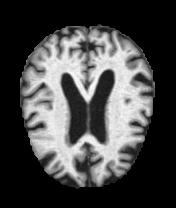

In [ ]:
mid_demented[0]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
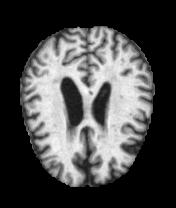

In [ ]:
moderate_demented[0]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
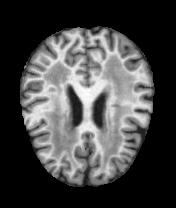

In [ ]:
non_demented[0]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
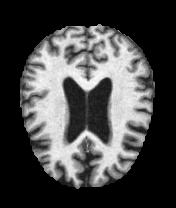

In [ ]:
highly_demented[0]

## 3.5.1 Visualización preliminar del dataset en escala de **grises**

En esta parte mostramos ejemplos del dataset de imágenes cerebrales, organizados en cuatro categorías:

mid_demented → demencia leve/media (10 imágenes)

moderate_demented → demencia moderada (10 imágenes)

non_demented → sin demencia (10 imágenes)

highly_demented → demencia severa/alta (10 imágenes)

Utilizamos Matplotlib para graficar las imágenes en escala de grises, lo que nos ayuda a validar que los datos se cargaron correctamente y, al mismo tiempo, observar de manera sencilla las diferencias visuales entre cada etapa del Alzheimer.

Observamos una muestra de 10 imágenes por cada categoría del dataset, mostrando los patrones visuales de las distintas etapas de la enfermedad de Alzheimer.  Matplotlib crea figuras grandes (25×8 o 25×10 pulgadas) y organiza las imágenes en cuadrículas de 6 filas por 10 columnas, aunque solo se muestran 10 imágenes por clase. Cada imagen se presenta en escala de grises, lo que facilita la percepción de texturas y patrones relevantes sin la distracción del color.

Se ocultan los ejes para centrar la atención únicamente en las imágenes, y cada figura lleva un título representativo de la categoría correspondiente. Esto permite verificar la correcta carga y distribución de las imágenes antes del preprocesamiento y modelado.

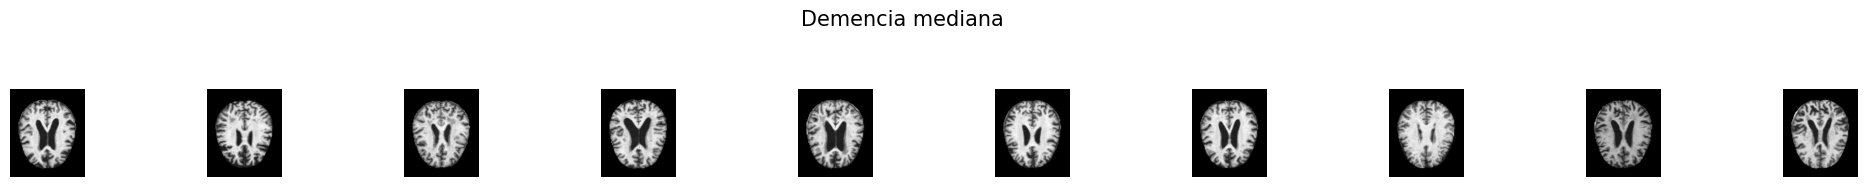

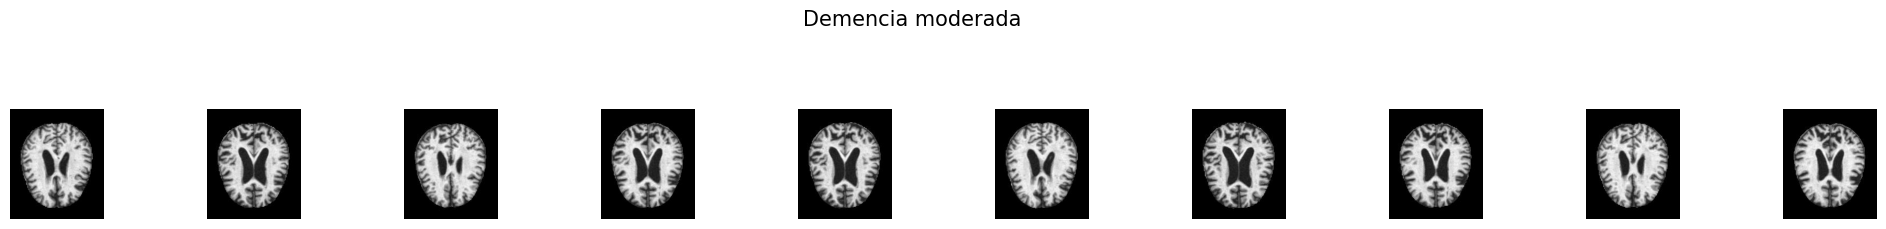

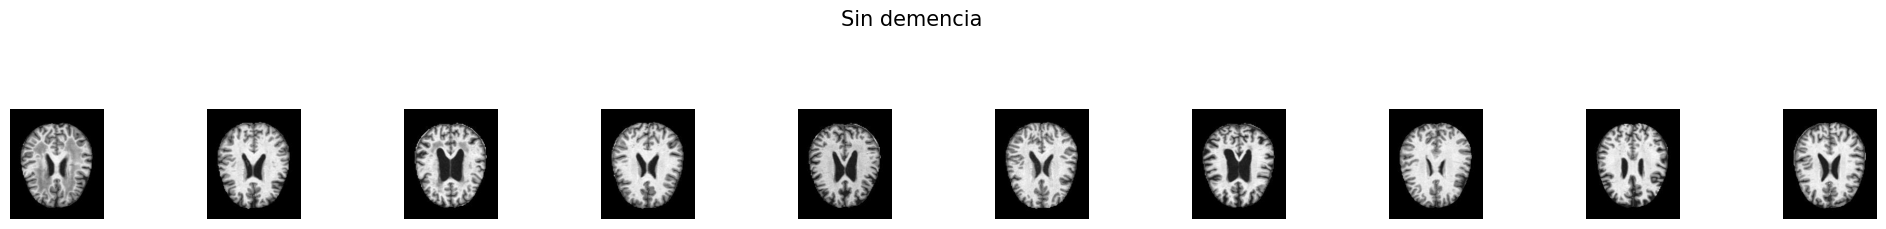

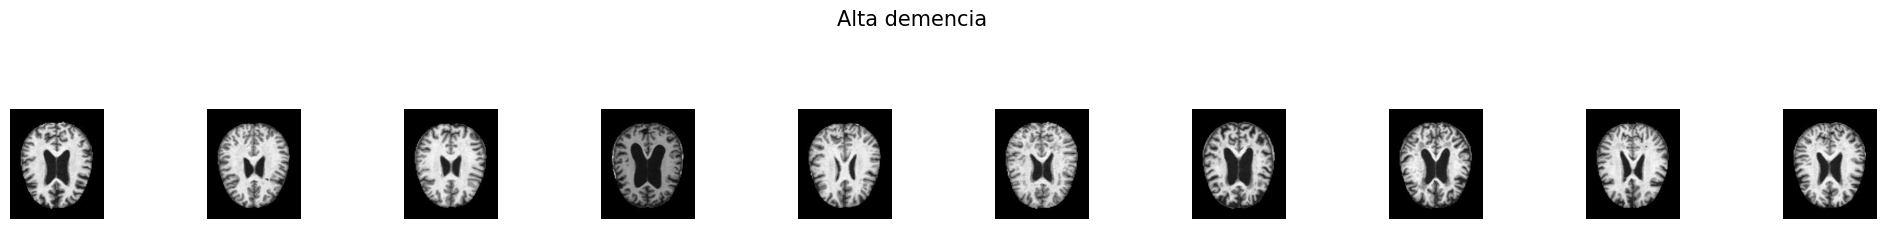

In [ ]:
plt.figure(figsize=(25,8))
c=1
for i in range(10):
    plt.subplot(6,10,c) #figure has 6 rows,10coloums and this is the first plot
    plt.imshow(mid_demented[i], 'gray') #'gary' represents pixels are to be in gray
    plt.axis('off')
    c+=1
plt.suptitle('Demencia mediana', size=15)
plt.show()


plt.figure(figsize=(25,10))
c=1
for i in range(10):
    plt.subplot(6,10,c)
    plt.imshow(moderate_demented[i], 'gray')
    plt.axis('off')
    c+=1
plt.suptitle('Demencia moderada', size=15)
plt.show()

plt.figure(figsize=(25,10))
c=1
for i in range(10):
    plt.subplot(6,10,c)
    plt.imshow(non_demented[i], 'gray')
    plt.axis('off')
    c+=1
plt.suptitle('Sin demencia', size=15)
plt.show()

plt.figure(figsize=(25,10))
c=1
for i in range(10):
    plt.subplot(6,10,c)
    plt.imshow(highly_demented[i], 'gray')
    plt.axis('off')
    c+=1
plt.suptitle('Alta demencia', size=15)
plt.show()

# 3.5.2 Visualización exploratoria con paleta PRGn

Siguiendo la fase de testeo de los datos, donde se verificó la correcta carga y categorización de las imágenes (non_demented, mid_demented, moderate_demented y highly_demented), se realiza ahora una visualización más detallada y atractiva utilizando la librería Matplotlib con la paleta Purple-Red-Green (PRGn). Al igual que en la revisión inicial en escala de grises, se muestran 10 imágenes por clase organizadas en cuadrículas, pero ahora el esquema cromático permite resaltar mejor los contrastes y patrones dentro de cada imagen, facilitando la comparación visual entre las distintas etapas de Alzheimer. Esta representación ayuda a confirmar la calidad de la carga de datos y ofrece un soporte visual más claro para el análisis exploratorio previo al procesamiento y modelamiento del dataset.

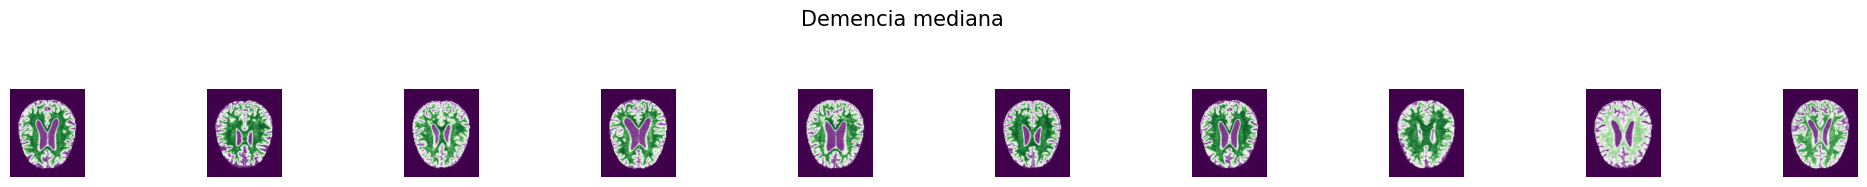

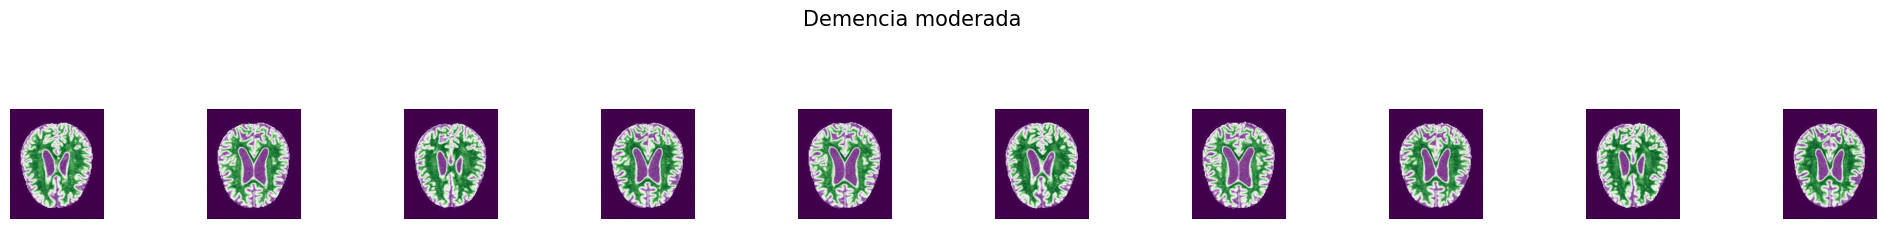

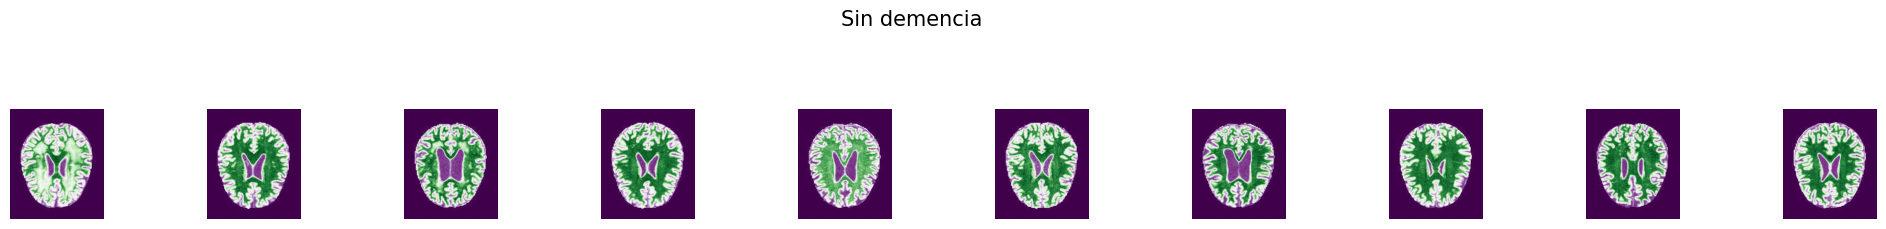

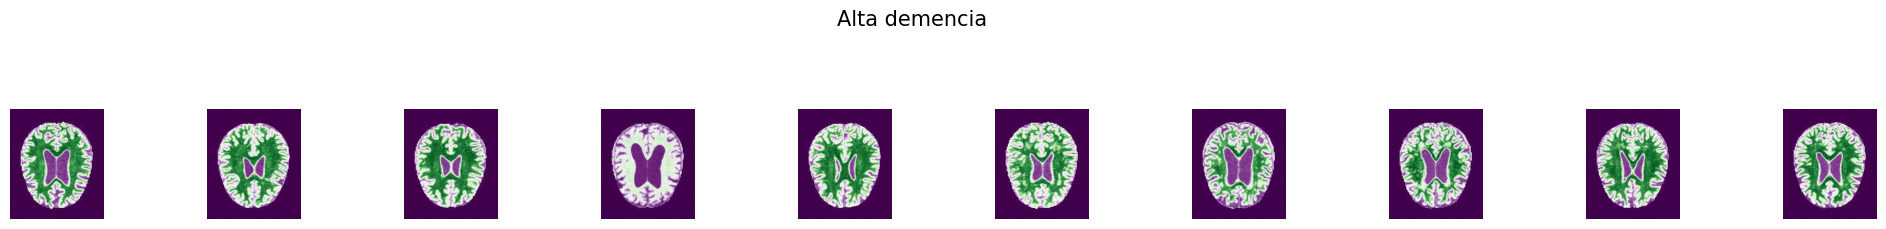

In [ ]:
plt.figure(figsize=(25,8))
c=1
for i in range(10):
    plt.subplot(6,10,c) #figure has 6 rows,10coloums and this is the first plot
    plt.imshow(mid_demented[i], 'PRGn') #'gary' represents pixels are to be in gray
    plt.axis('off')
    c+=1
plt.suptitle('Demencia mediana', size=15)
plt.show()


plt.figure(figsize=(25,10))
c=1
for i in range(10):
    plt.subplot(6,10,c)
    plt.imshow(moderate_demented[i], 'PRGn')
    plt.axis('off')
    c+=1
plt.suptitle('Demencia moderada', size=15)
plt.show()

plt.figure(figsize=(25,10))
c=1
for i in range(10):
    plt.subplot(6,10,c)
    plt.imshow(non_demented[i], 'PRGn')
    plt.axis('off')
    c+=1
plt.suptitle('Sin demencia', size=15)
plt.show()

plt.figure(figsize=(25,10))
c=1
for i in range(10):
    plt.subplot(6,10,c)
    plt.imshow(highly_demented[i], 'PRGn')
    plt.axis('off')
    c+=1
plt.suptitle('Alta demencia', size=15)
plt.show()

# 3.5.3 Visualización exploratoria con paleta BWR



Se emplea nuevamente Matplotlib, pero esta vez **con** la paleta Blue-White-Red (BWR). En esta etapa se generan figuras que muestran 10 imágenes representativas por cada categoría: demencia mediana, demencia moderada, sin demencia y alta demencia. El esquema cromático BWR acentúa las diferencias de intensidad entre los píxeles, pasando del azul al rojo mediante tonos blancos intermedios, lo que permite resaltar patrones y variaciones visuales relevantes dentro de cada grupo. Esta visualización complementa la revisión previa en PRGn, ofreciendo un contraste distinto que facilita la interpretación de las características distintivas de cada etapa de la enfermedad.

---







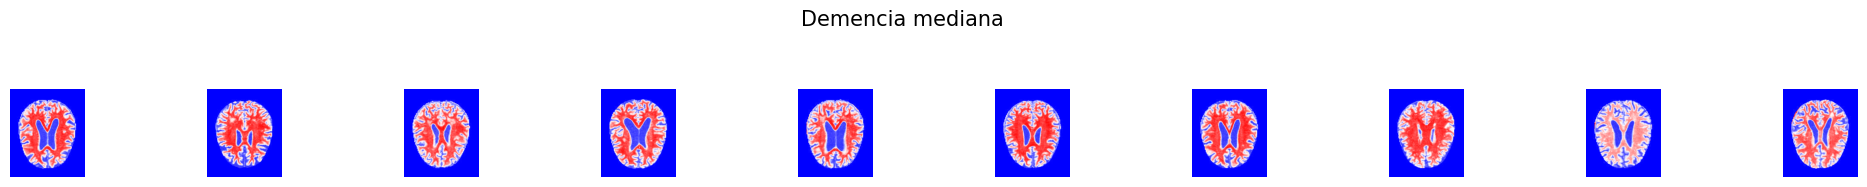

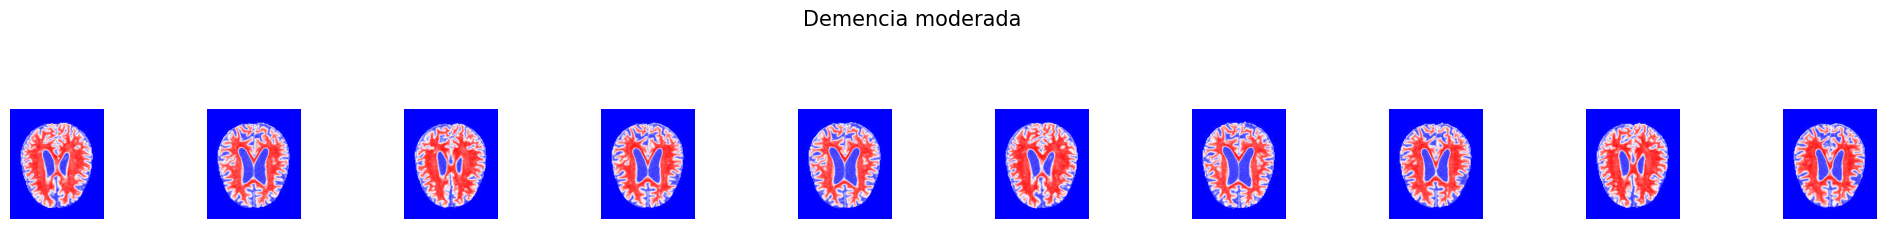

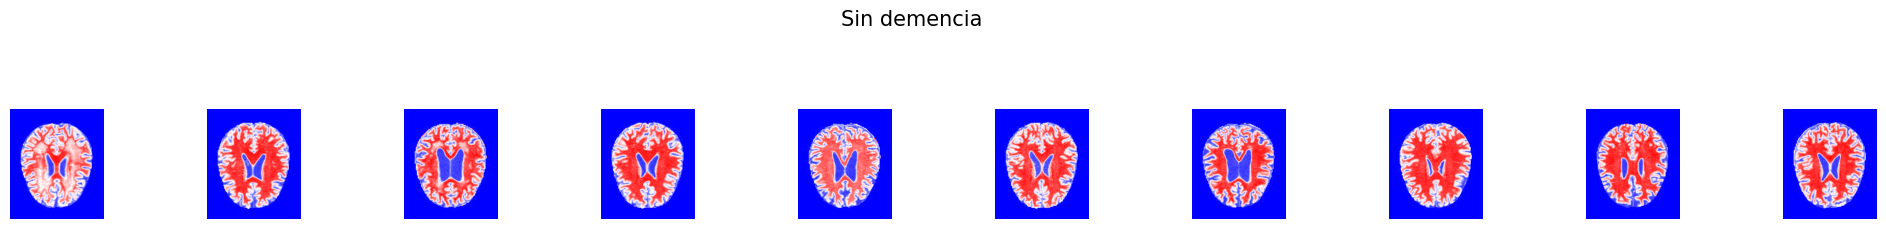

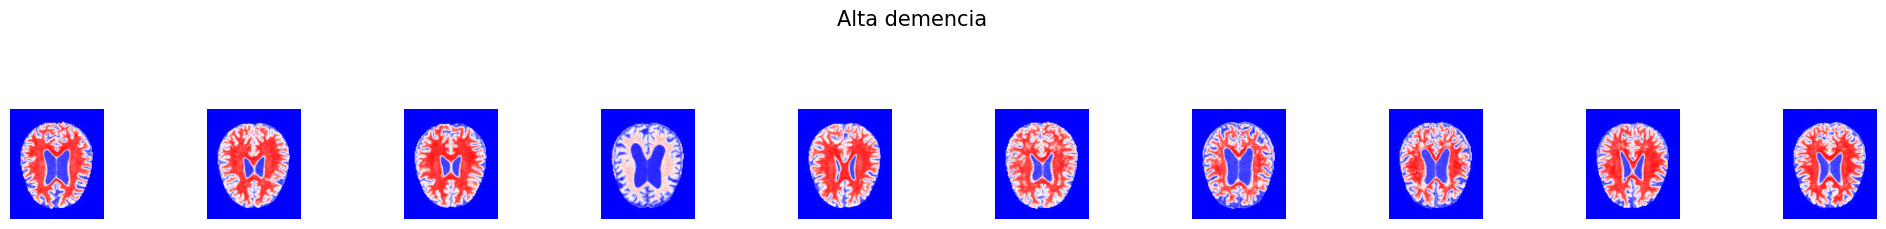

In [ ]:
plt.figure(figsize=(25,8))
c=1
for i in range(10):
    plt.subplot(6,10,c) #figure has 6 rows,10coloums and this is the first plot
    plt.imshow(mid_demented[i], 'bwr') #'gary' represents pixels are to be in gray
    plt.axis('off')
    c+=1
plt.suptitle('Demencia mediana', size=15)
plt.show()


plt.figure(figsize=(25,10))
c=1
for i in range(10):
    plt.subplot(6,10,c)
    plt.imshow(moderate_demented[i], 'bwr')
    plt.axis('off')
    c+=1
plt.suptitle('Demencia moderada', size=15)
plt.show()

plt.figure(figsize=(25,10))
c=1
for i in range(10):
    plt.subplot(6,10,c)
    plt.imshow(non_demented[i], 'bwr')
    plt.axis('off')
    c+=1
plt.suptitle('Sin demencia', size=15)
plt.show()

plt.figure(figsize=(25,10))
c=1
for i in range(10):
    plt.subplot(6,10,c)
    plt.imshow(highly_demented[i], 'bwr')
    plt.axis('off')
    c+=1
plt.suptitle('Alta demencia', size=15)
plt.show()

# **3.6 Normalización de los datos**

Aplicamos la normalización de las imágenes mediante las funciones de contraste, ya que estas ajustan los valores de los píxeles para que estén en un rango más uniforme y resaltan las diferencias de intensidad.

### 3.6.1. Equalized Hist

Con la técnica de Equalized Histogram (Histograma Ecualizado) redistribuimos los valores de intensidad de la imagen para aumentar su contraste general. Esto permite normalizar visualmente las áreas oscuras y claras, haciendo más perceptibles los detalles. La función adaptive_hist aplica la técnica de ecualización adaptativa de histograma (CLAHE) para mejorar el contraste de las imágenes. El proceso convierte la imagen del espacio de color BGR al espacio Lab, separa el canal de luminancia (L) y ajusta su contraste dividiéndolo en pequeñas regiones controladas por un límite (clipLimit). Luego, los canales se vuelven a unir y la imagen es reconvertida a BGR, obteniendo así un resultado con mayor nitidez y detalle, sin alterar significativamente los colores originales.

In [ ]:
#Adaptive histogram equalization: AHE used to increase contrast of the image
def adaptive_hist(img, clipLimit= 4.0):
    window= cv2.createCLAHE(clipLimit= clipLimit, tileGridSize=(8, 8))
            #contrast limited AHE(CLAHE) it limits the amplification by cliping the histogram at a predefined value before compate.
            #tilegridsize refers to size of grid for histogram equation input image will be divided into equally sized rectanglar tiles. tile grid size defines the number of tiles in row, color.
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)
            #cv2.cvtcolor(img,code)
            #code:color space conversion code
            #cv2.cv2color-BGR2Lab: This code is used to change the BGR color space to Lab color space

    ch1, ch2, ch3 = cv2.split(img_lab)
            #cv2,split() function splits the source multichannel img to several channel images

    img_l = window.apply(ch1)
    img_clahe = cv2.merge((img_l, ch2, ch3))
    return cv2.cvtColor(img_clahe, cv2.COLOR_Lab2BGR)
           #cv2.merge function merges several single-channel images into multichannel image.

## 3.6.2. K-Means clustering

Con la técnica de K-Means clustering se busca simplificar la imagen reduciendo la cantidad de colores a un número definido por el usuario (n_colors). La función k_means realiza una segmentación de la imagen aplicando el algoritmo K-Means, donde cada píxel se asigna al color más representativo de su grupo, generando así una versión simplificada de la imagen que resalta las regiones dominadas por los colores principales. Esto permite resaltar patrones y estructuras relevantes dentro de la imagen.

Para ello, primero se normalizan los valores de los píxeles dividiéndolos entre 255, escalando los datos entre 0 y 1. Luego, la imagen se reorganiza en un arreglo bidimensional donde cada fila representa un píxel y sus canales de color. Sobre este arreglo se aplica K-Means, obteniendo un "codebook" que representa los colores centrales de cada grupo. Finalmente, se reconstruye la imagen asignando a cada píxel el color de su cluster correspondiente, generando una versión segmentada que mantiene la estructura general de la imagen pero enfatiza los patrones de intensidad de manera más clara.

In [ ]:

def k_means(img, n_colors= 2):
    w, h, d = original_shape = tuple(img.shape)
    img= img/255.0

    image_array = np.reshape(img, (w * h, d))
    kmeans = KMeans(n_clusters=n_colors, random_state=0).fit(image_array)
    labels = kmeans.predict(image_array)

    """Recreate the (compressed) image from the code book & labels"""
    codebook= kmeans.cluster_centers_
    d = codebook.shape[1]
    image = np.zeros((w, h, d))
    label_idx = 0
    for i in range(w):
        for j in range(h):
            image[i][j] = codebook[labels[label_idx]]
            label_idx += 1
    return image

## 3.6.3. Visualización comparativa de imágenes

Veremos 2 ejemplos donde se ve la diferencia entre las imagenes originales y las que se convirtieron con las funciones definidas


### Ejemplo 1

En este ejemplo se selecciona una imagen de la categoría demencia media y se visualizan tres versiones distintas para apreciar los efectos de las técnicas de procesamiento aplicadas.

Text(0.5, 0.98, 'Demencia media')

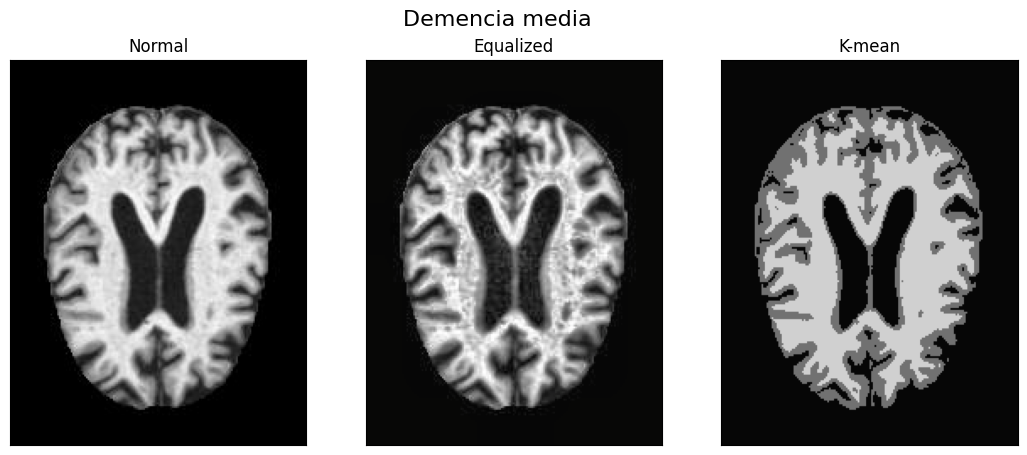

In [ ]:
img_path= '/content/drive/MyDrive/test/MildDemented/26 (19).jpg'

f, ax= plt.subplots(1, 3, figsize=(13,5))
img= cv2.imread(img_path)
eq_hist_img= adaptive_hist(img)
kmeans_img= k_means(img,3)

ax[0].imshow(img, aspect='auto')
ax[0].set_xticks([]); ax[0].set_yticks([]); ax[0].set_title('Normal')
ax[1].imshow(eq_hist_img,  aspect='auto')
ax[1].set_xticks([]); ax[1].set_yticks([]); ax[1].set_title('Equalized')
ax[2].imshow(kmeans_img,  aspect='auto')
ax[2].set_xticks([]); ax[2].set_yticks([]); ax[2].set_title('K-mean')

plt.suptitle('Demencia media', size=16)

Imagen original: cargada directamente desde la ruta indicada, mostrando cómo se ve la imagen sin ninguna modificación.

Imagen con ecualización adaptativa de histograma (CLAHE): aplicada mediante la función adaptive_hist, que mejora el contraste de la imagen resaltando detalles importantes.

Imagen segmentada con K-Means: generada por la función k_means con 3 colores, que simplifica la imagen resaltando regiones dominantes según los colores principales.

Cada versión se grafica lado a lado en una cuadrícula de 1 fila y 3 columnas usando Matplotlib, con los ejes ocultos y títulos individuales para cada técnica, permitiendo comparar visualmente cómo cada método modifica la imagen y facilita la observación de patrones relevantes para el análisis del Alzheimer.

### Ejemplo 2

En este ejemplo se selecciona una imagen de la categoría demencia moderada y se muestran tres versiones para comparar los efectos de las técnicas de procesamiento aplicadas.

Text(0.5, 0.98, 'Demencia moderada')

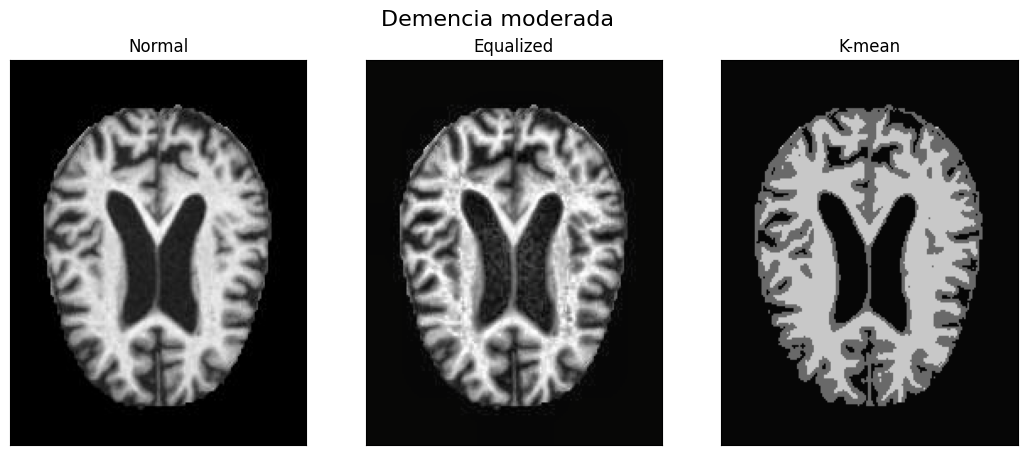

In [ ]:

img_path= '/content/drive/MyDrive/test/ModerateDemented/27 (2).jpg'

f, ax= plt.subplots(1, 3, figsize=(13,5))
img= cv2.imread(img_path)
eq_hist_img= adaptive_hist(img)
kmeans_img= k_means(img,3)

ax[0].imshow(img, aspect='auto')
ax[0].set_xticks([]); ax[0].set_yticks([]); ax[0].set_title('Normal')
ax[1].imshow(eq_hist_img,  aspect='auto')
ax[1].set_xticks([]); ax[1].set_yticks([]); ax[1].set_title('Equalized')
ax[2].imshow(kmeans_img,  aspect='auto')
ax[2].set_xticks([]); ax[2].set_yticks([]); ax[2].set_title('K-mean')

plt.suptitle('Demencia moderada', size=16)

Se aprecia una comparación visual de una imagen de la categoría “demencia moderada” utilizando tres versiones diferentes: la imagen original, la imagen con ecualización adaptativa de histograma (CLAHE) para mejorar el contraste, y la imagen segmentada mediante K-Means con 3 colores para resaltar las regiones dominantes. Cada versión se muestra lado a lado en una cuadrícula de 1 fila y 3 columnas, con títulos individuales y ejes ocultos, permitiendo observar cómo cada técnica enfatiza detalles distintos y facilita la identificación de patrones relevantes para el análisis de las distintas etapas del Alzheimer.

### 3.3.3. Ejemplo 3

En este caso, se selecciona una imagen de la categoría sin demencia y se presentan tres versiones para observar los efectos de las técnicas de procesamiento.

Text(0.5, 0.98, 'Sin demencia')

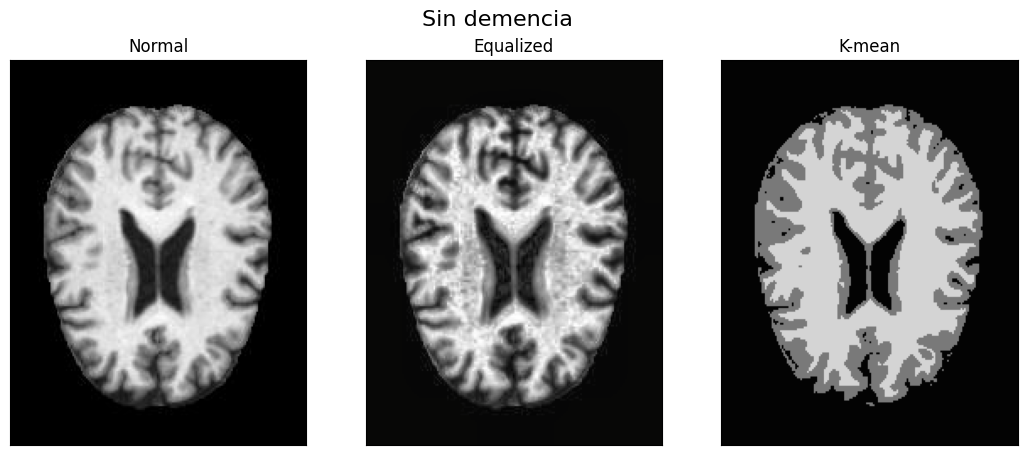

In [ ]:
img_path= '/content/drive/MyDrive/test/NonDemented/26 (62).jpg'

f, ax= plt.subplots(1, 3, figsize=(13,5))
img= cv2.imread(img_path)
eq_hist_img= adaptive_hist(img)
kmeans_img= k_means(img,3)

ax[0].imshow(img, aspect='auto')
ax[0].set_xticks([]); ax[0].set_yticks([]); ax[0].set_title('Normal')
ax[1].imshow(eq_hist_img,  aspect='auto')
ax[1].set_xticks([]); ax[1].set_yticks([]); ax[1].set_title('Equalized')
ax[2].imshow(kmeans_img,  aspect='auto')
ax[2].set_xticks([]); ax[2].set_yticks([]); ax[2].set_title('K-mean')

plt.suptitle('Sin demencia', size=16)

La primera corresponde a la imagen original (Normal) tal como fue cargada con OpenCV. La segunda aplica la función adaptive_hist, que implementa la ecualización adaptativa de histograma (CLAHE), mejorando el contraste y haciendo más visibles los detalles (Equalized). Finalmente, la tercera versión aplica el algoritmo K-Means con tres colores (K-mean) para segmentar la imagen, asignando a cada píxel el color más representativo de su grupo y resaltando las regiones predominantes.

Las tres imágenes se presentan lado a lado en una cuadrícula de 1 fila y 3 columnas, con títulos individuales y ejes ocultos. Esta visualización comparativa permite observar cómo cada técnica modifica la imagen, resalta diferentes patrones y facilita la identificación de características importantes para el posterior análisis con modelos de Deep Learning.

### 3.3.4. Ejemplo 4

Aquí se presenta una imagen de la categoría “demencia alta” mostrando tres versiones: la original, la imagen con ecualización adaptativa de histograma (CLAHE) para realzar el contraste, y la segmentada mediante K-Means con 3 colores para destacar las regiones predominantes.

Text(0.5, 0.98, 'Demencia alta')

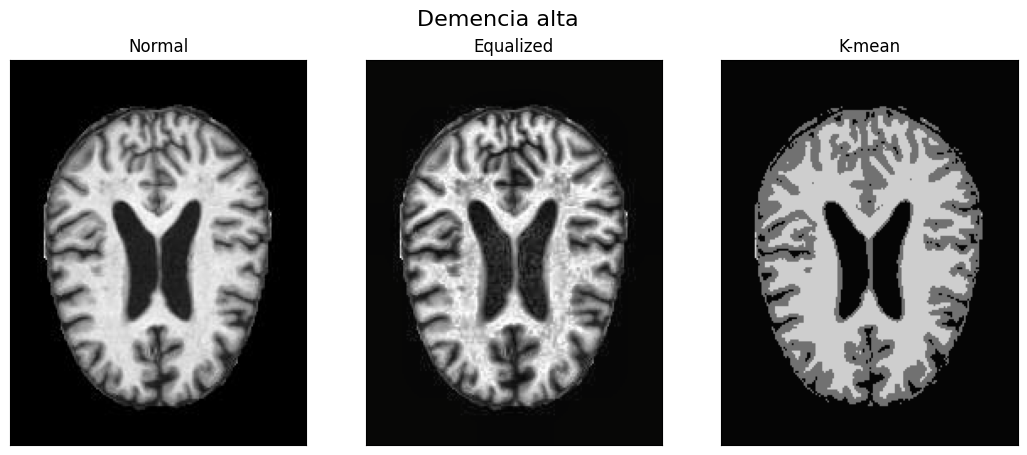

In [ ]:
|img_path= '/content/drive/MyDrive/test/VeryMildDemented/26 (44).jpg'

f, ax= plt.subplots(1, 3, figsize=(13,5))
img= cv2.imread(img_path)
eq_hist_img= adaptive_hist(img)
kmeans_img= k_means(img,3)

ax[0].imshow(img, aspect='auto')
ax[0].set_xticks([]); ax[0].set_yticks([]); ax[0].set_title('Normal')
ax[1].imshow(eq_hist_img,  aspect='auto')
ax[1].set_xticks([]); ax[1].set_yticks([]); ax[1].set_title('Equalized')
ax[2].imshow(kmeans_img,  aspect='auto')
ax[2].set_xticks([]); ax[2].set_yticks([]); ax[2].set_title('K-mean')

plt.suptitle('Demencia alta', size=16)

La primera es la imagen original (Normal) cargada con OpenCV. La segunda corresponde al resultado de la ecualización adaptativa de histograma (Equalized) mediante la función adaptive_hist, la cual redistribuye los valores de intensidad para mejorar el contraste y resaltar detalles poco visibles. Finalmente, la tercera versión aplica el algoritmo K-Means con tres colores (K-mean), que segmenta la imagen agrupando los píxeles según los colores predominantes, lo que facilita identificar estructuras y patrones relevantes.

Las tres representaciones se muestran en una cuadrícula de 1 fila y 3 columnas, con títulos específicos y ejes ocultos. Esta disposición comparativa permite observar de forma clara cómo cada técnica transforma la imagen, destacando diferentes aspectos que pueden ser útiles en el análisis de imágenes médicas y en la detección de Alzheimer en etapas avanzadas.


### 3.6.4. Visualización de las categorías según los bordes (Canny Edge Detection)

En esta etapa se aplicó el detector de bordes de Canny, precedido de un filtrado con mediana para reducir el ruido y preservar mejor las estructuras de las imágenes cerebrales. El objetivo de esta técnica es resaltar los contornos principales presentes en cada categoría, lo que facilita la identificación de patrones estructurales que podrían diferenciar a los pacientes según el nivel de demencia.

Las visualizaciones se organizaron por categoría en cuadrículas, mostrando ejemplos representativos de:

Sin demencia

Demencia mediana

Demencia moderada

Alta demencia

Cada conjunto se presenta en escala de grises (cmap: 'gray') para destacar únicamente los bordes detectados. Este enfoque resulta útil como preprocesamiento exploratorio, ya que permite identificar diferencias en la definición de contornos y en la complejidad estructural entre clases, las cuales pueden ser relevantes en el entrenamiento posterior de modelos de Deep Learning.

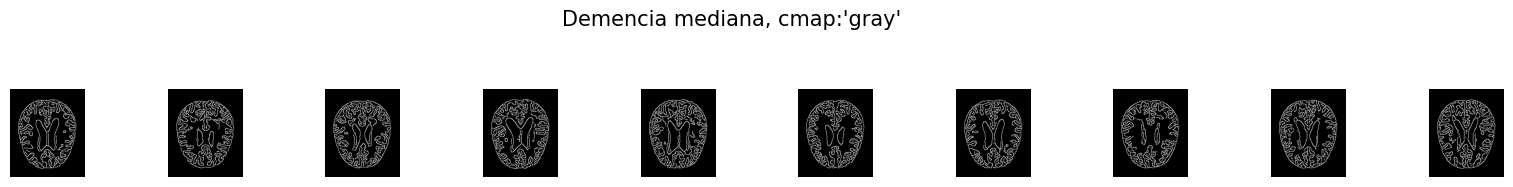

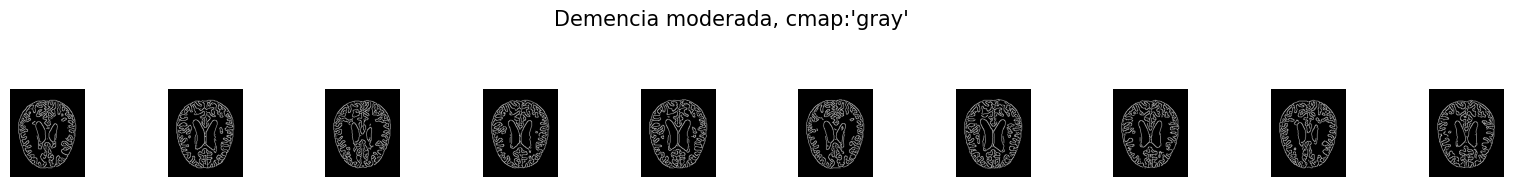

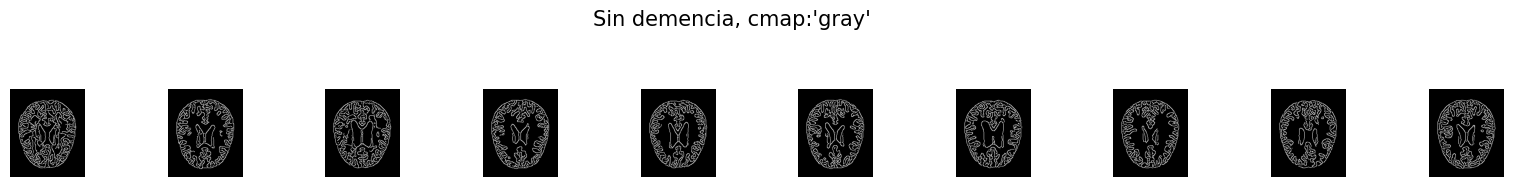

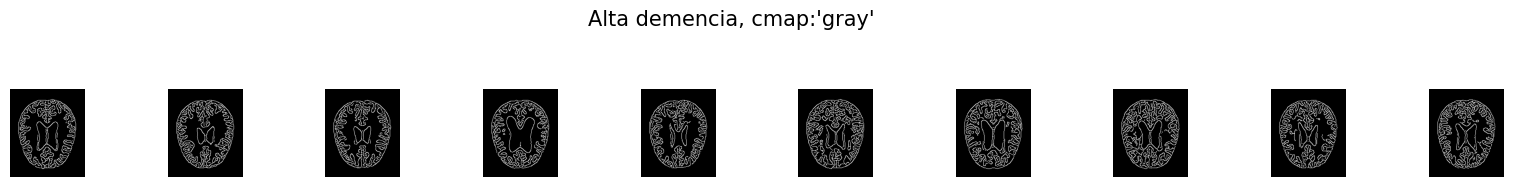

In [ ]:
plt.figure(figsize=(20,8))
c=1
for i in range(10):
    plt.subplot(6,10,c)
    ed= cv2.medianBlur(mid_demented[i], 5)
    ed= cv2.Canny(ed,100,20)
    plt.imshow(ed, 'gray')
    plt.axis('off')
    c+=1
plt.suptitle("Demencia mediana, cmap:'gray'", size=15)
plt.show()

plt.figure(figsize=(20,8))
c=1
for i in range(10):
    plt.subplot(6,10,c)
    ed= cv2.medianBlur(moderate_demented[i], 5)
    ed= cv2.Canny(ed,100,20)

    plt.imshow(ed, 'gray')
    plt.axis('off')
    c+=1
plt.suptitle("Demencia moderada, cmap:'gray'", size=15)
plt.show()

plt.figure(figsize=(20,8))
c=1
for i in range(10):
    plt.subplot(6,10,c)
    ed= cv2.medianBlur(non_demented[i], 5)

    ed= cv2.Canny(ed,100,20)
    plt.imshow(ed, 'gray')
    plt.axis('off')
    c+=1
plt.suptitle("Sin demencia, cmap:'gray'", size=15)
plt.show()


plt.figure(figsize=(20,8))
c=1
for i in range(10):
    plt.subplot(6,10,c)
    ed= cv2.medianBlur(highly_demented[i], 5)

    ed= cv2.Canny(ed,100,20)

    plt.imshow(ed, 'gray')
    plt.axis('off')
    c+=1
plt.suptitle("Alta demencia, cmap:'gray'", size=15)
plt.show()


Este paso permite resaltar patrones y estructuras clave en las imágenes médicas, facilitando su análisis y posterior procesamiento para el modelado del Alzheimer.

# **4. Modelamiento**

Se importaran las librerias a utilizar:

1. LAYERS: Cada capa recibe información de entrada, realiza algunos cálculos y finalmente genera la información transformada. La salida de una capa fluirá a la siguiente capa como su entrada.
2. MODEL: El modelo agrupa capas en un objeto con funciones de entrenamiento e inferencia
3. Clasification_report: El visualizador de informes de clasificación muestra las puntuaciones de precisión, recuperación, F1 y soporte para el modelo.
4. Confusion_matrix: La matriz compara los valores objetivo reales con los predichos por el modelo de aprendizaje automático.
5. Acurracy_score: La precisión es la medida de rendimiento más intuitiva y es simplemente una relación entre la observación predicha correctamente y el total de observaciones.

In [ ]:
import tensorflow


from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras import layers, Input

from tensorflow.keras.models import Model

from sklearn.metrics import classification_report,confusion_matrix, accuracy_score
from keras.utils import plot_model

En esta sección se importan las librerías necesarias para el desarrollo del modelo de deep learning. Se incluye TensorFlow y Keras, específicamente la arquitectura VGG16 y sus funciones de preprocesamiento (preprocess_input), además de módulos para construir y personalizar modelos (layers, Input, Model). También se importan herramientas de evaluación de desempeño, como classification_report, confusion_matrix y accuracy_score de scikit-learn, así como plot_model de Keras para visualizar la arquitectura de la red. Estas importaciones preparan el entorno para entrenar, evaluar y analizar un modelo de clasificación de imágenes del Alzheimer.

## 4.1. Split Train / Test

Como se aprecia, ambas funciones son similares con la diferencia del parametro "subset", que es justamente en el que definiremos que dataset usaremos para entrenar y cual para validar.

La función image_dataset_from_directory toma como entrada la ruta a un directorio que contiene imágenes organizadas en subdirectorios, donde cada subdirectorio representa una clase de imágenes diferente. La función devuelve un objeto de tipo tf.data.Dataset que contiene las imágenes cargadas y preprocesadas, listas para usarse para el entrenamiento o la evaluación de un modelo de aprendizaje profundo.

El preprocesamiento incluye tareas como la lectura de archivos de imagen en tensores, la conversión a un formato adecuado para el modelo (por ejemplo, escala de grises o RGB), y la normalización de los datos. La función image_dataset_from_directory también proporciona una serie de opciones para personalizar el preprocesamiento, como la conversión a un tamaño específico, la rotación o el recorte de las imágenes, entre otros.

Se tiene el primer parametro que es la ruta del directorio de donde se sacaran las imagenes.

Segundo parametro es la data de validacion que se cogera 20% para validacion y 80% para entrenamiento

En el subset se especifica que data sera, si de "training" o de "validacion"

Seed es la semilla que se define 123 en este caso

Image_size es el shape de las imagenes que redimensionara

Batch size: este parametro es importante ya que se optmizara el entrenamiento, haciendolo mas rapido y eficaz, ademas de poder escoger de paquetes de 32 imagenes para el testeo y validacion.



In [ ]:
train_data_dir= '/content/drive/MyDrive/train'
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

train_data = image_dataset_from_directory(
                  train_data_dir,
                  validation_split=0.2,
                  subset="training",
                  seed=123,
                  image_size=(224, 224),
                  batch_size=32)


val_data = image_dataset_from_directory(train_data_dir,
                                        validation_split=0.2,
                                        subset="validation",
                                        seed=123,
                                        image_size=(224,224),
                                        batch_size=32)

Found 687 files belonging to 3 classes.
Using 550 files for training.
Found 687 files belonging to 3 classes.
Using 137 files for validation.


In [ ]:
for images, labels in val_data.take(1):
  print("Ejecutado Correctamente")

Ejecutado Correctamente


Imprimiremos las etiquetas y podemos observar 4 clases

In [ ]:
print(val_data.class_names)

['MildDemented', 'ModerateDemented', 'NonDemented']


In [ ]:
print(labels)

tf.Tensor([0 0 0 0 0 0 0 0 2 2 0 0 0 0 2 0 0 0 0 0 0 2 0 0 1 0 2 0 0 0 0 0], shape=(32,), dtype=int32)


## 4.2. Construyendo el modelo

### 4.2.1. Sequential

Se usara el modelo Sequential. Es un tipo de modelo de aprendizaje profundo en TensorFlow que consiste en una secuencia lineal de capas de redes neuronales. Cada capa de un modelo Sequential recibe como entrada las salidas de la capa anterior y produce una nueva salida que se pasa como entrada a la siguiente capa. La última capa produce la salida final del modelo.

* Capa 1 layers.Rescaling: Esta capa escala los valores de los píxeles de las imágenes de entrada de (0, 255) a (0, 1). La forma de entrada es de (224, 224, 3), lo que significa que se esperan imágenes de 224x224 píxeles con 3 canales (rojo, verde y azul).

* Capa 2 layers.Conv2D: Esta es una capa de convolución 2D, que se utiliza para extraer características de las imágenes de entrada. Hay tres capas de convolución, cada una con un número diferente de filtros (16, 32 y 64). Los parámetros de tamaño de kernel (3) y padding ('same') significan que se utilizará un kernel de tamaño 3x3 y que se agregará un borde de píxeles para que la salida tenga la misma forma que la entrada. La función de activación utilizada es la función ReLU (Rectified Linear Unit).

* Capa 3 layers.MaxPooling2D: Esta es una capa de pooling 2D, que se utiliza para reducir la dimensionalidad de los mapas de características generados por las capas de convolución. Se aplica después de cada capa de convolución.

* Capa 4 layers.Conv2D

* Capa 5 layers.MaxPooling2D

* Capa 6 layers.Conv2D

* Capa 7 layers.MaxPooling2D

* Capa 8 layers.Dropout: Esta es una capa de dropout, que se utiliza para prevenir el sobreajuste. El valor de 0.5 significa que el 50% de los nodos se apagarán en cada iteración del entrenamiento.

* Capa 9 layers.Flatten: Esta es una capa de aplanamiento, que convierte los mapas de características en un vector 1D para su procesamiento por la capa densa.

* Capa 10 layers.Dense: Esta es una capa densa, que es una capa totalmente conectada. Hay dos capas densas, cada una con un número diferente de nodos (128 y 4).
* Capa 11 La función de activación utilizada en la última capa es la función softmax, que proporciona una distribución de probabilidad sobre 4 categorías diferentes.


In [ ]:

def build_model():
    model = tf.keras.Sequential([

    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Dropout(0.5),
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(4,activation="softmax")
  ])

    return model

El método compile en un modelo de redes neuronales en Keras es utilizado para configurar el proceso de entrenamiento. El método compile toma tres argumentos principales:

1. optimizer: especifica el optimizador que se utilizará para actualizar los pesos de la red neuronal durante el entrenamiento. Hay varios optimizadores disponibles en Keras, como SGD, Adam, RMSprop, entre otros.

2. loss: especifica la función de pérdida que se utilizará para medir el error durante el entrenamiento. Hay varias funciones de pérdida disponibles en Keras, como mean_squared_error, categorical_crossentropy, binary_crossentropy, entre otras.

3. metrics: es una lista de métricas que se utilizarán para evaluar el rendimiento del modelo durante el entrenamiento y la validación. Por ejemplo, se puede especificar accuracy para calcular la precisión del modelo.

Una vez que se han especificado los argumentos en el método compile, el modelo está listo para ser entrenado con datos de entrenamiento. El proceso de entrenamiento actualizará los pesos de la red neuronal de manera que la función de pérdida sea la mínima posible.

In [ ]:
from tensorflow.keras.optimizers import Adam
model= build_model()
#model.compile(loss= tensorflow.keras.losses.BinaryCrossentropy(),
#              optimizer=tensorflow.keras.optimizers.Adam(0.0002), metrics=['accuracy'])
model.compile(optimizer="Adam",
            loss=tf.keras.losses.SparseCategoricalCrossentropy(),
            metrics=["accuracy"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


A continuacion se puede ver el modelo de forma grafica, el modelo cuenta con 11 capas

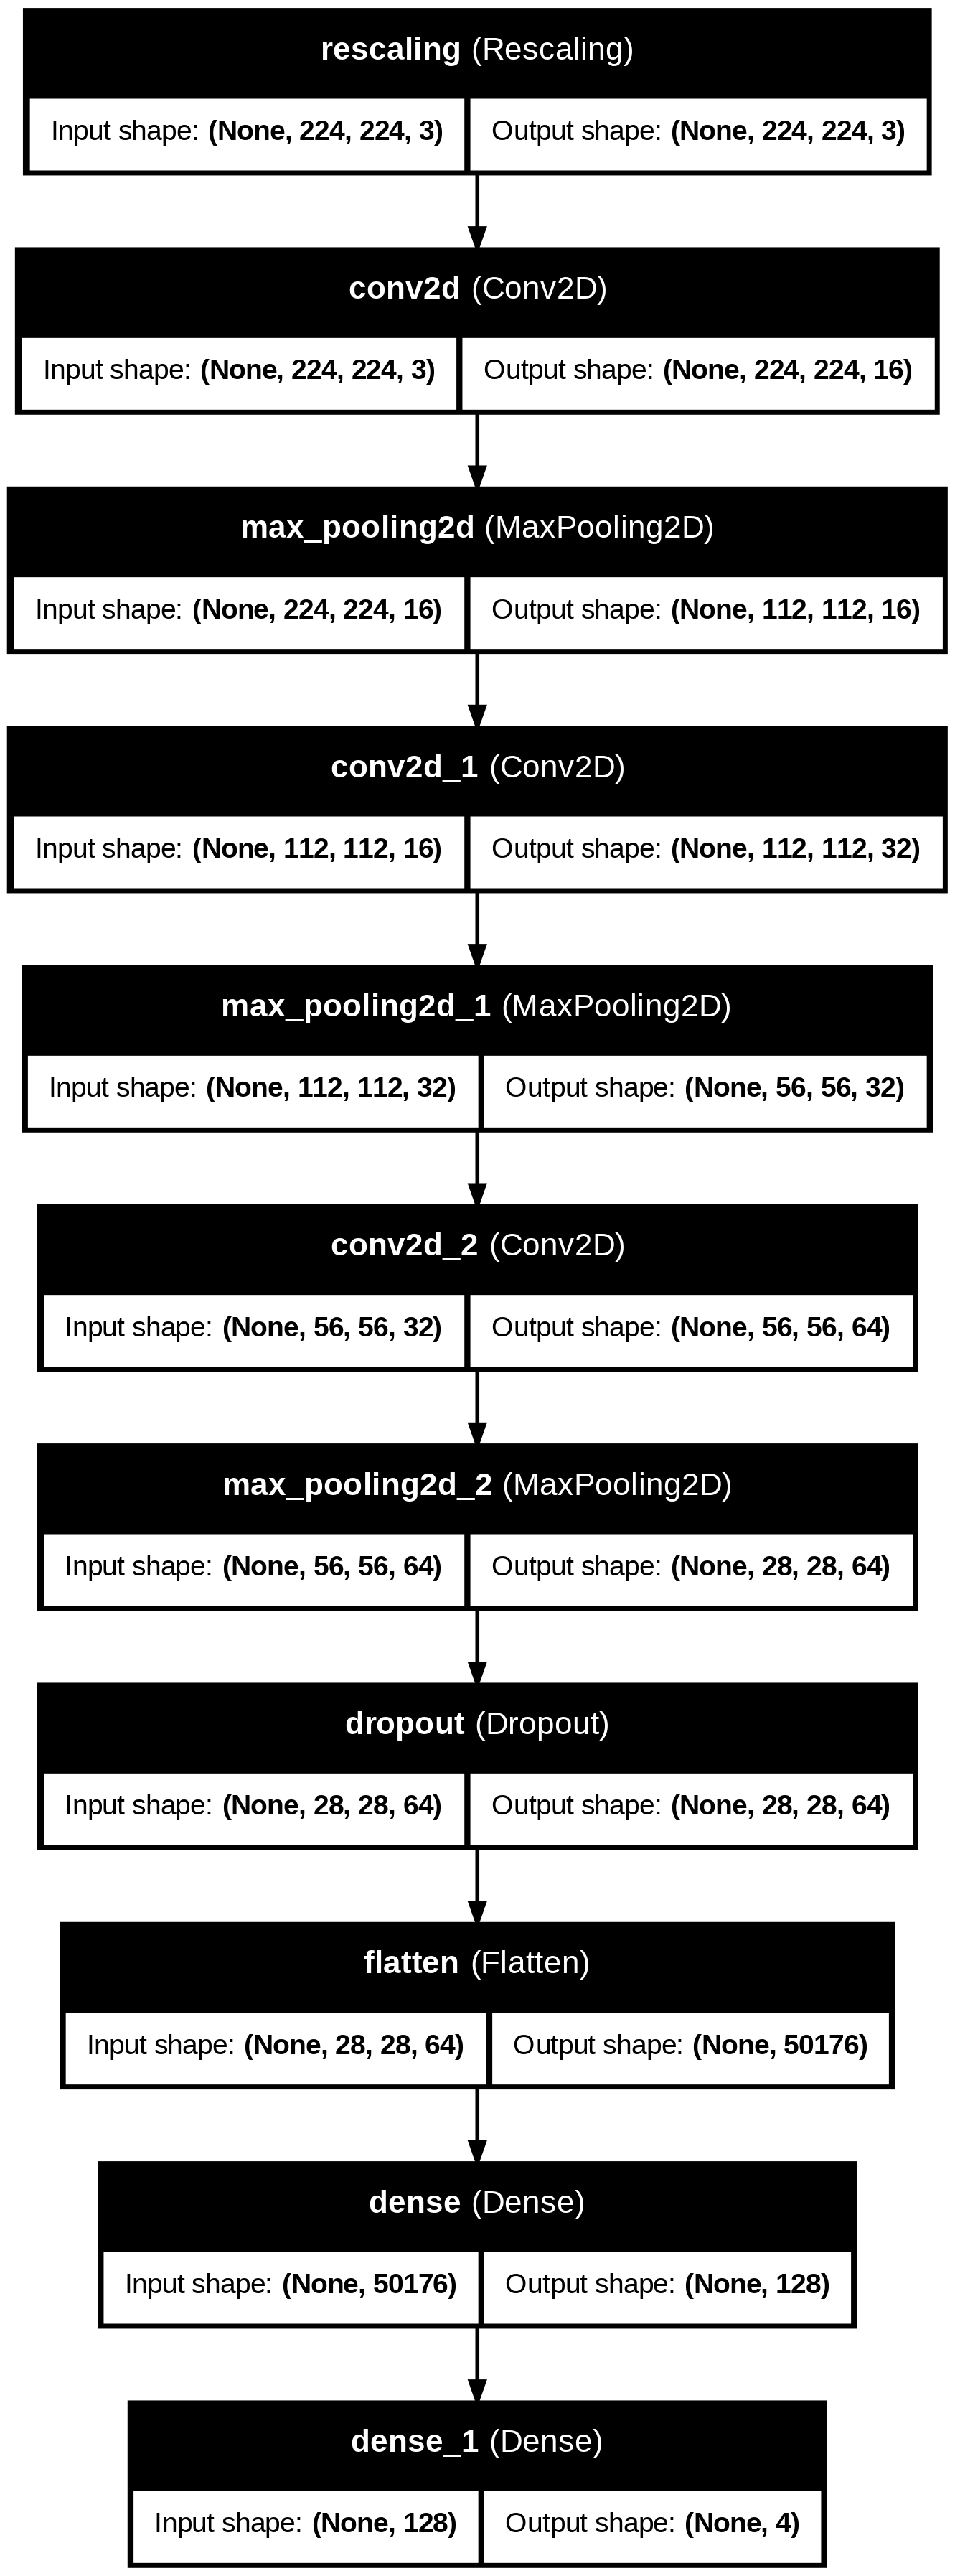

In [ ]:
plot_model(
   model,
    to_file='model.png',
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    rankdir='TB',
    expand_nested=True,
    dpi=200,
    layer_range=None,
    show_layer_activations=False
)

El resumen del modelo

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,446,756 (24.59 MB)

 Trainable params: 6,446,756 (24.59 MB)

 Non-trainable params: 0 (0.00 B)

### 4.2.2. Early Stoppin & ModelCheckpoint

1. EarlyStopping es una técnica de detención temprana en el entrenamiento de redes neuronales en Keras. La idea detrás de EarlyStopping es detener el entrenamiento de una red neuronal cuando la función de pérdida de validación deje de mejorar durante un número determinado de épocas consecutivas.
Esto es útil ya que, a menudo, una red neuronal puede seguir entrenándose durante muchas épocas sin mejorar su rendimiento en el conjunto de validación. En estos casos, detener el entrenamiento temprano puede ayudar a evitar el sobreajuste (overfitting) y mejorar la generalización del modelo a nuevos datos.
2. ModelCheckpoint es una clase de "callback" en Keras que permite guardar el modelo en el disco durante y después del entrenamiento. Con ModelCheckpoint, se puede especificar una condición para guardar el modelo, por ejemplo, después de cada época o solo cuando la función de pérdida de validación mejore. Esto permite recuperar el modelo después de una interrupción en el entrenamiento o continuar el entrenamiento desde donde se detuvo.



In [ ]:
early_stop= tensorflow.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                     mode='min', verbose=1, patience=4)

check= tensorflow.keras.callbacks.ModelCheckpoint(
    '/content/drive/MyDrive/alz_model_trained.weights.h5', monitor='val_loss', verbose=1, save_best_only=True,
    save_weights_only=True, mode='min', save_freq='epoch')

## 4.3. Entrenamiento del modelo

Luego de haber definido el modelo y sus parametros necesarios, se procede a entrenar.

Se puede ver que estamos usando el train_generator como base para entrenamiento, los pasos por epoch segun las imagenes de ejemplo, la data de validacion se usara las imagenes que se definieron para test. Por ultimo en callback se parasarn los parametros check y early_stop previamente explicados

In [ ]:
history = model.fit(train_data,
                    epochs=7,
                    validation_data=val_data,
                    batch_size=32
                    ,callbacks=[check, early_stop])

Epoch 1/7
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6273 - loss: 1.1034
Epoch 1: val_loss improved from inf to 0.63712, saving model to /content/drive/MyDrive/alz_model_trained.weights.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.6310 - loss: 1.0947 - val_accuracy: 0.7883 - val_loss: 0.6371
Epoch 2/7
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7341 - loss: 0.7252
Epoch 2: val_loss improved from 0.63712 to 0.59493, saving model to /content/drive/MyDrive/alz_model_trained.weights.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.7344 - loss: 0.7236 - val_accuracy: 0.8175 - val_loss: 0.5949
Epoch 3/7
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7460 - loss: 0.6234
Epoch 3: val_loss improved from 0.59493 to 0.53434, saving model to /content/drive/MyDrive/alz_model_trained.weights.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.7470 - loss: 0.6208 - val_accuracy: 0.7956 - val_loss: 0.5343
Epoch 4/7
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc

# **5. Evaluacion del rendimiento del Modelo**


# Evolución de la Pérdida y precisión

En esta etapa se analizan dos métricas fundamentales durante el entrenamiento del modelo: la pérdida (loss) y la precisión (accuracy). La gráfica de la izquierda muestra cómo la pérdida disminuye progresivamente a medida que avanzan las épocas, lo cual indica que el modelo logra un mejor ajuste a los datos. La gráfica de la derecha evidencia que la precisión aumenta tanto en entrenamiento como en validación, reflejando una mejora en la capacidad del modelo para clasificar correctamente las imágenes.


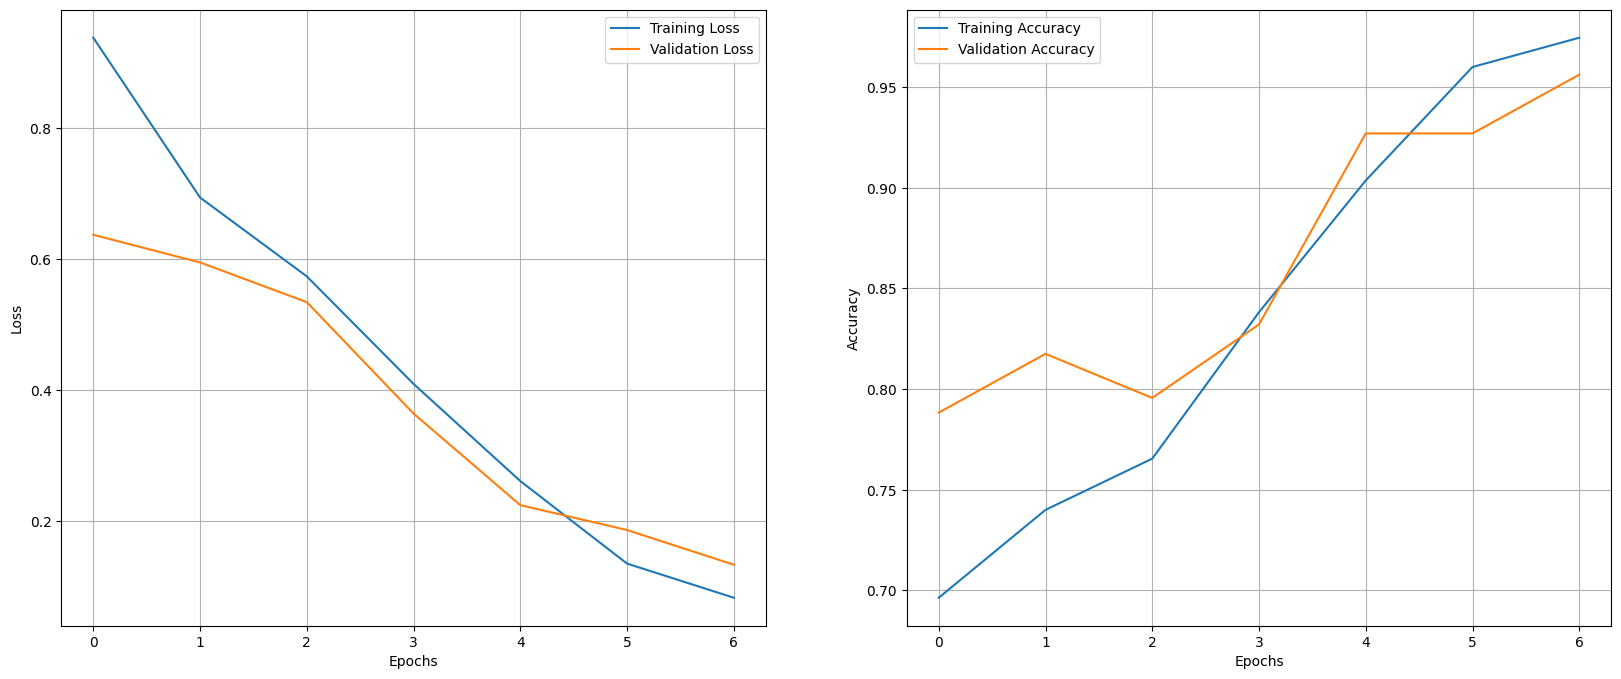

In [ ]:
plt.figure(1, figsize = (20, 8))
plt.subplot(1,2,1)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.plot( history.history["loss"], label = "Training Loss")
plt.plot( history.history["val_loss"], label = "Validation Loss")
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.plot( history.history["accuracy"], label = "Training Accuracy")
plt.plot( history.history["val_accuracy"], label = "Validation Accuracy")
plt.grid(True)
plt.legend()

Las curvas de pérdida (loss) y precisión (accuracy) muestran una evolución coherente tanto en entrenamiento como en validación. La pérdida disminuye progresivamente y la precisión aumenta de forma consistente en ambos conjuntos, sin una separación marcada entre las curvas, a medida que aumentan . Esto indica que el modelo está aprendiendo de manera adecuada y logra generalizar correctamente, sin evidencias significativas de sobreajuste.

# Reconstrucción del modelo

En esta fase se reconstruye el modelo mediante la función build_model(), con el objetivo de poder cargar el modelo previamente entrenado y almacenado en Google Drive. Posteriormente, se compila utilizando el optimizador Adam, la función de pérdida SparseCategoricalCrossentropy() (adecuada para problemas de clasificación multiclase con etiquetas enteras) y la métrica de evaluación accuracy, que mide la proporción de predicciones correctas.

In [ ]:
model= build_model()
model.compile(optimizer="Adam",
            loss=tf.keras.losses.SparseCategoricalCrossentropy(),
            metrics=["accuracy"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Cargamos el modelo y testeamos



In [ ]:
model.load_weights('/content/drive/MyDrive/alz_model_trained.weights.h5')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
class_names = val_data.class_names

In [ ]:
print(class_names)

['MildDemented', 'ModerateDemented', 'NonDemented']


De esta manera hacemos una prediccion por cada Batch que se definio en la data de validacion, 30 "take" de 32 imagenes cada uno con un total de 960 predicciones que hara a continuacion

In [ ]:
import numpy as np
predict_labels=[]
true_labels=[]

for images, labels in val_data.take(30):
    # Usar len(labels) para obtener el tamaño real del batch
    for i in range(len(labels)):  # Cambiado de range(32) a range(len(labels))
        img = images[i].numpy().astype("uint8")
        img = tf.expand_dims(img, axis=0)
        predictions = model.predict(img, verbose=0)  # verbose=0 para evitar spam
        predicted_class = np.argmax(predictions)
        predict_labels.append(class_names[predicted_class])
        true_labels.append(class_names[labels[i]])



# Matriz de confusión y métricas clásicas

Se usara de skleanr, las metricas para medir en una matriz de confusion con los resultados de nuestro modelo

In [ ]:
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt

# EVLUANDO LA MATRIZ DE CONFUSION
#--------------------------------------------------------------------
conf_mat = confusion_matrix(y_true=true_labels, y_pred=predict_labels)
#--------------------------------------------------------------------

Se observa que nuestro modelo logró predecir correctamente la gran mayoría de los casos, alcanzando 131 aciertos de un total de 137 muestras evaluadas. Esto significa que únicamente se produjeron 6 errores de clasificación, lo cual refleja un desempeño sólido y consistente en la tarea de predicción.

In [ ]:
print('Matriz de Confusión :\n', conf_mat)

Matriz de Confusión :
 [[107   0   1]
 [  0   7   0]
 [  5   0  17]]


A continuacion se puede ver de mejor manera, el recall, la precision y el grafico de la matriz de confusion

Métricas de Matriz de Confusión:
                   precision    recall  f1-score   support

    MildDemented       0.96      0.99      0.97       108
ModerateDemented       1.00      1.00      1.00         7
     NonDemented       0.94      0.77      0.85        22

        accuracy                           0.96       137
       macro avg       0.97      0.92      0.94       137
    weighted avg       0.96      0.96      0.95       137



/tmp/ipython-input-374019301.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + labels)
/tmp/ipython-input-374019301.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + labels)


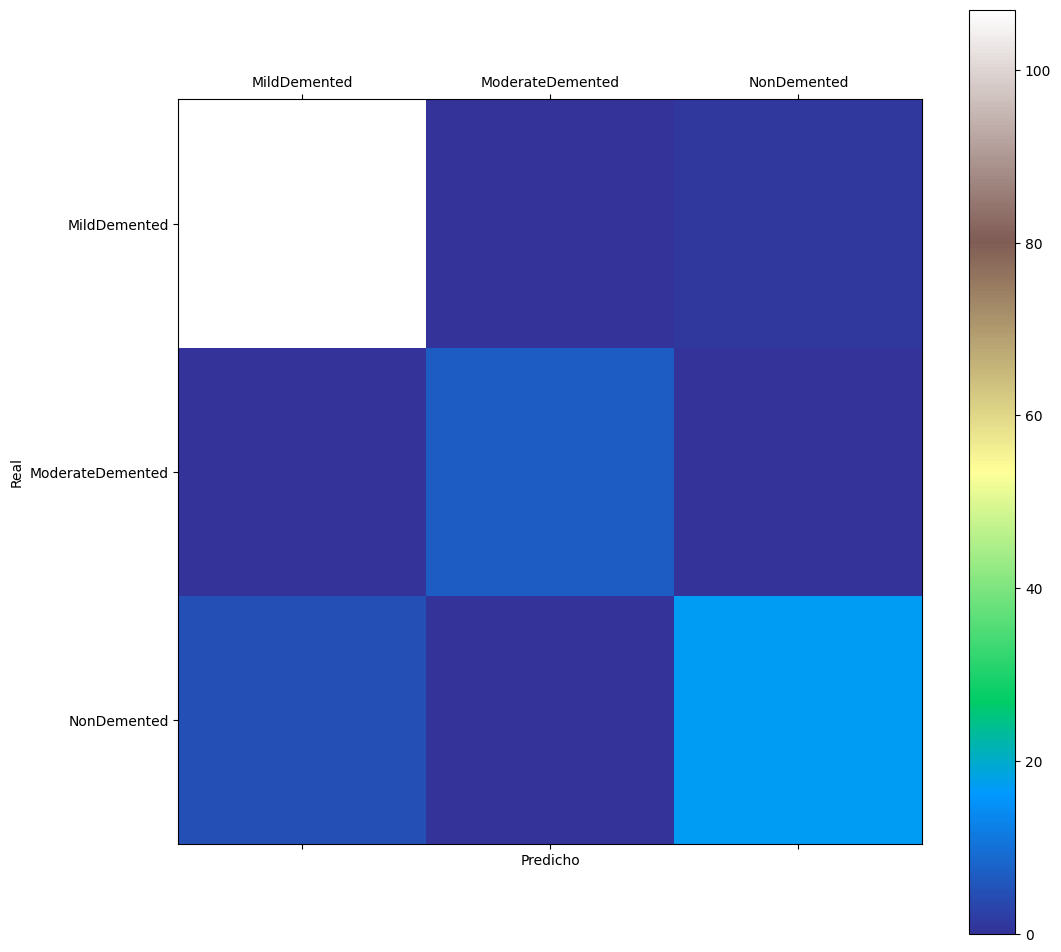

In [ ]:
print('Métricas de Matriz de Confusión:\n',classification_report(true_labels,predict_labels))

labels = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111)
cax = ax.matshow(conf_mat, cmap=plt.cm.terrain)
fig.colorbar(cax)
ax.set_xticklabels([''] + labels)
ax.set_yticklabels([''] + labels)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

El modelo alcanzó una exactitud global (accuracy) del 96%, mostrando un desempeño robusto en la clasificación de las distintas categorías de demencia.

MildDemented: obtuvo una precisión del 96% y un recall del 99%, lo que indica que prácticamente todos los casos leves fueron identificados correctamente, con muy pocos falsos negativos.

ModerateDemented: logró un desempeño perfecto, con precisión, recall y F1-score del 100%, reflejando una clasificación exacta de todos los casos moderados.

NonDemented: alcanzó una precisión del 94%, aunque con un recall menor (77%), lo que sugiere que algunos individuos sin demencia fueron clasificados erróneamente en otra categoría.

En términos generales, las métricas de macro promedio (precision: 97%, recall: 92%, F1: 94%) y promedio ponderado (precision: 96%, recall: 96%, F1: 95%) confirman que el modelo mantiene un equilibrio adecuado en su desempeño, aunque aún presenta un margen de mejora en la detección de los casos sin demencia.

# Visualización de *resultados*

A continuacion graficaremos los resultados de nuestro modelo, poniendo "TRUE" si fue satisfactorio y "FALSE" si fue un error, a la izquierda se mostrara el resultado que nuestro modelo predijo, y a la derecha el Real. Apreciaremos las predicciones correctas e incorrectas del modelo.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━

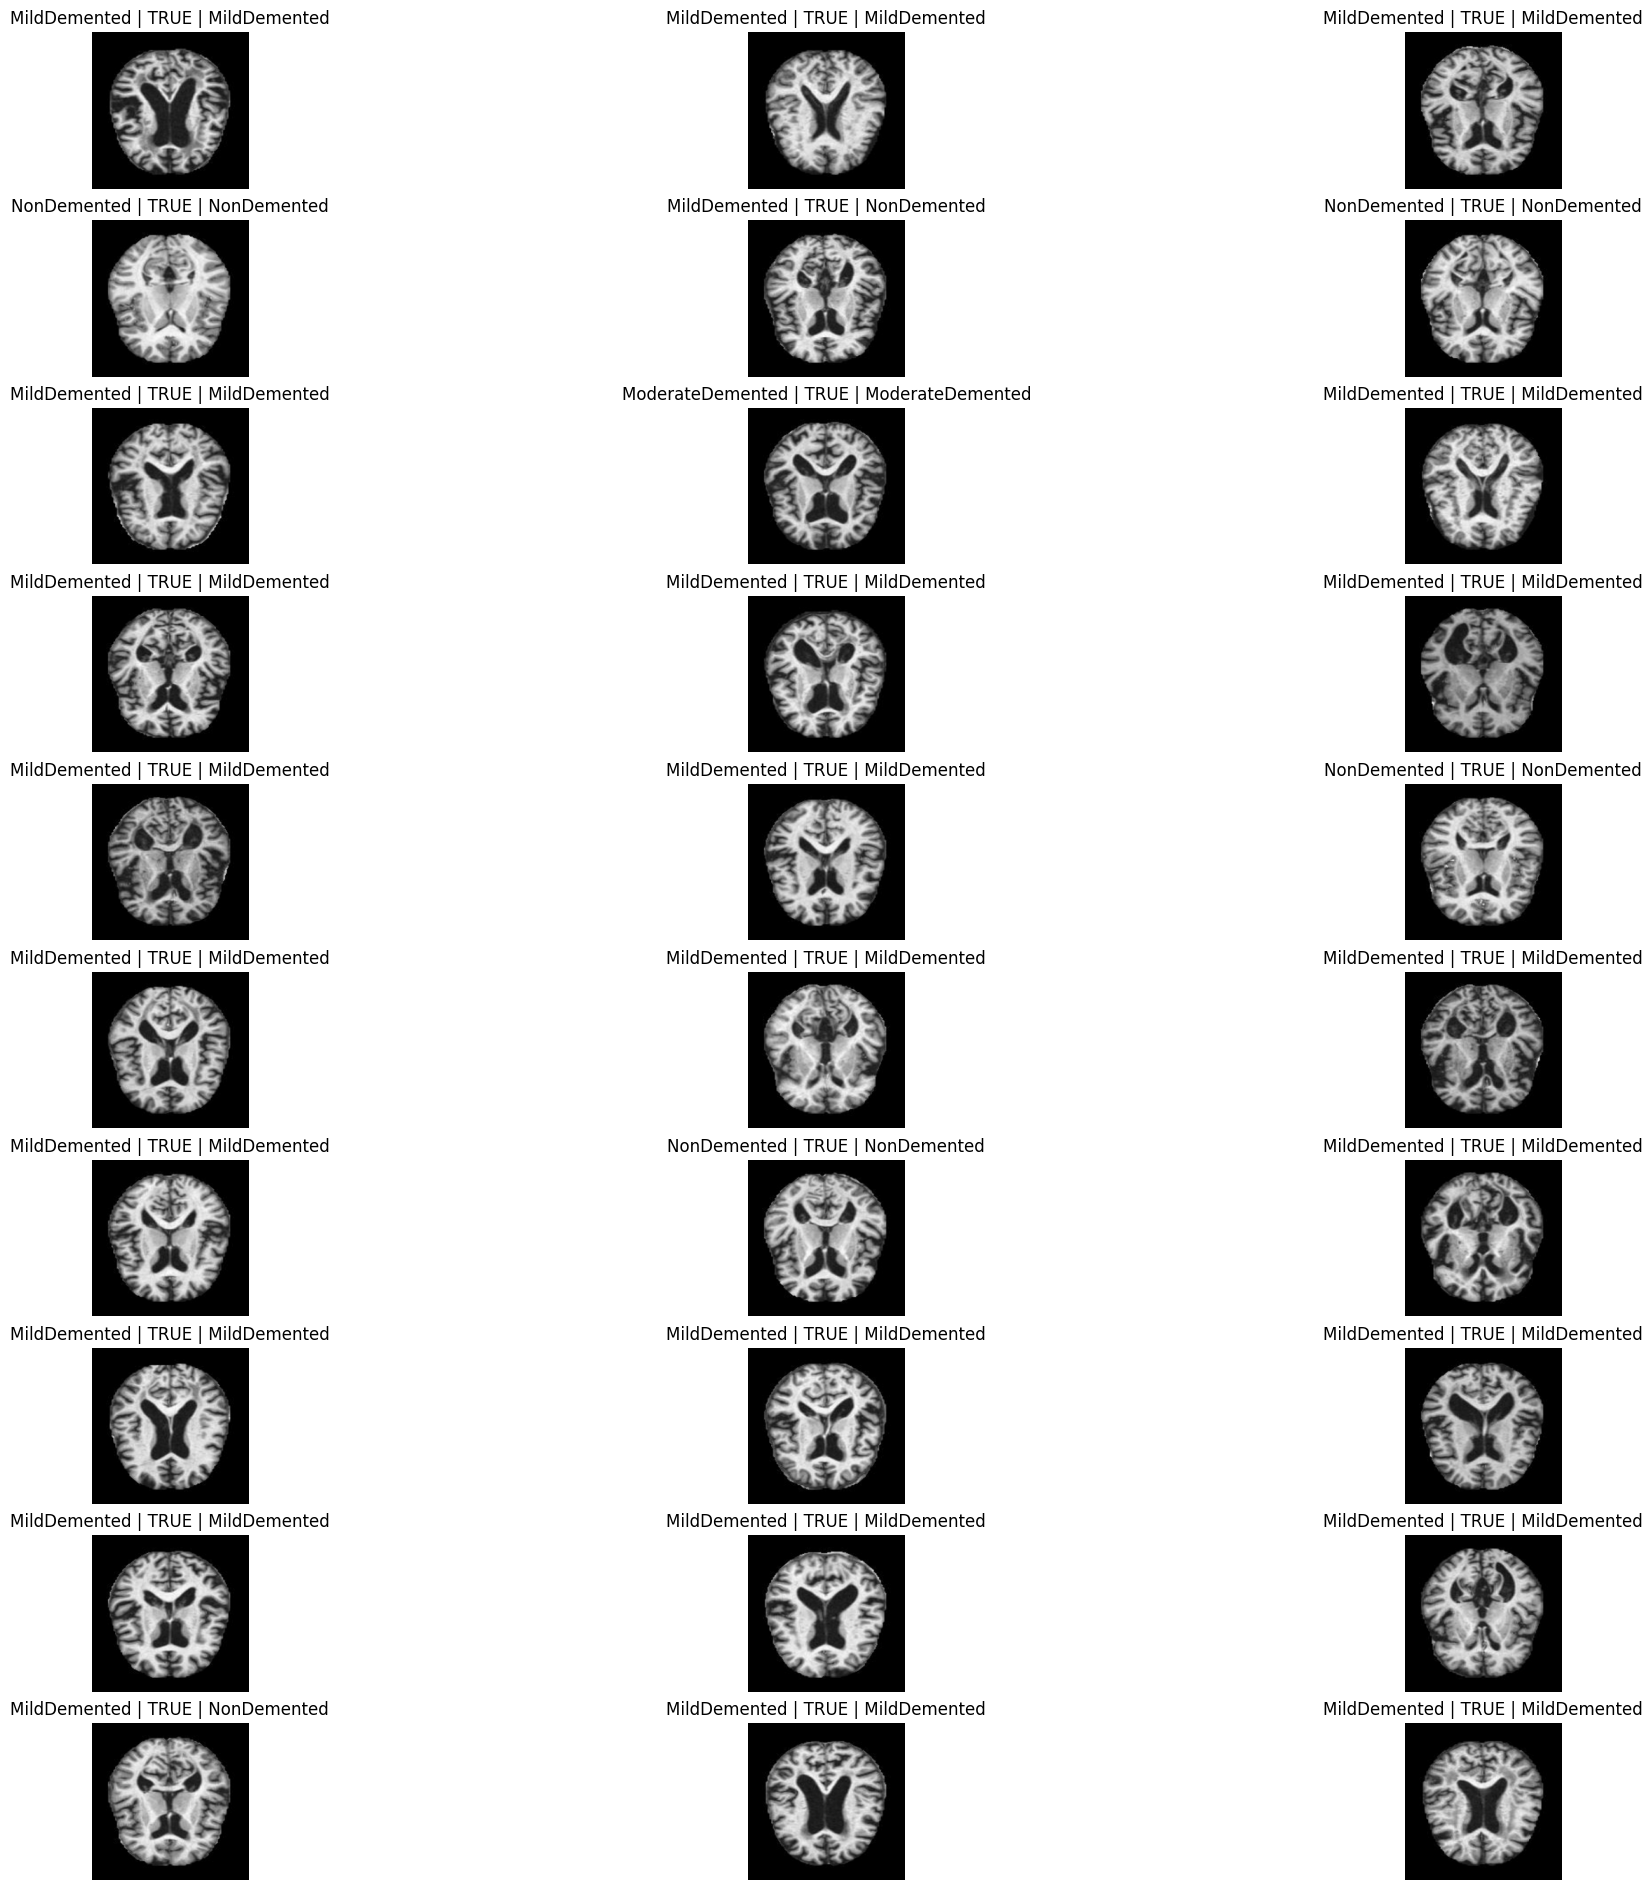

In [ ]:
plt.figure(figsize=(24, 24))

result = ' | False'
for images, labels in val_data.take(1):
    for i in range(30):

        ax = plt.subplot(10, 3, i + 1)

        img = images[i].numpy().astype("uint8")
        img = tf.expand_dims(img, axis=0)

        predictions = model.predict(img)
        predicted_class = np.argmax(predictions)

        if class_names[predicted_class] == class_names[labels[i]]:
            result = ' | TRUE'

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[predicted_class]+result+' | '+  class_names[labels[i]])
        plt.axis("off")



```
# Tiene formato de código
```

## Metricas Adicionales

*Evaluación completa del modelo en el conjunto de validación*

Se procesó la totalidad del dataset de validación (137 muestras distribuidas en 5 lotes). Durante la evaluación, se registraron tanto las etiquetas verdaderas como las predicciones realizadas por el modelo.

La distribución de clases es la siguiente:

| Clase            | Verdaderos | % Real | Predichos | % Predicho | Diferencia |
| ---------------- | ---------- | ------ | --------- | ---------- | ---------- |
| MildDemented     | 108        | 78.8%  | 112       | 81.8%      | **+3.0%**  |
| ModerateDemented | 7          | 5.1%   | 7         | 5.1%       | 0.0%       |
| NonDemented      | 22         | 16.1%  | 18        | 13.1%      | **–3.0%**  |


🔎 Análisis comparativo

El modelo sobrepredice la clase MildDemented (+3%), lo cual puede deberse a que es la clase mayoritaria en el dataset.

La clase ModerateDemented se mantiene con una predicción exacta en proporción, aunque el bajo número de muestras hace que sea más difícil generalizar conclusiones sólidas.

La clase NonDemented se ve ligeramente subrepresentada (–3%), indicando que algunos de sus casos se clasifican como MildDemented.

✅ En general, el modelo reproduce correctamente la distribución de clases, con desviaciones menores que pueden atribuirse al desbalance en los datos y a la mayor representatividad de la categoría MildDemented.

*Evaluación completa del modelo en el dataset de validación*

En esta fase se procesó todo el conjunto de validación (137 imágenes en 5 lotes) para obtener las predicciones completas del modelo.

Durante la evaluación se registraron:

Etiquetas verdaderas (ground truth).

Clases predichas por el modelo.

Probabilidades de salida (para métricas como ROC-AUC).

Al finalizar, se obtuvo la siguiente distribución de clases:

| Clase            | Verdaderos | % Real | Predichos | % Predicho | Diferencia |
| ---------------- | ---------- | ------ | --------- | ---------- | ---------- |
| MildDemented     | 108        | 78.8%  | 112       | 81.8%      | **+3.0%**  |
| ModerateDemented | 7          | 5.1%   | 7         | 5.1%       | 0.0%       |
| NonDemented      | 22         | 16.1%  | 18        | 13.1%      | **–3.0%**  |

Interpretación:

El modelo mantiene una predicción bastante equilibrada respecto a la realidad.

Se observa una sobrepredicción de la clase MildDemented (+3%), lo que puede estar asociado a su predominio en el dataset.

La clase ModerateDemented fue clasificada correctamente en su totalidad, aunque el bajo número de muestras no permite aún una generalización sólida.

La clase NonDemented aparece subrepresentada (–3%), lo que indica que algunos casos fueron confundidos con MildDemented.

⚖️ En conjunto, el modelo reproduce de manera fiel la distribución de clases y confirma un rendimiento sólido en validación, aunque con una ligera tendencia hacia la clase mayoritaria (MildDemented).

In [ ]:

# Limpiar variables anteriores
predict_labels = []
true_labels = []
y_scores = []

print("="*50)
print("INICIANDO EVALUACIÓN COMPLETA DEL MODELO")
print("="*50)

# Procesar TODO el dataset de validación (sin límite de batches)
print("\nProcesando todo el dataset de validación...")
batch_count = 0

for images, labels in val_data:  # Sin .take() para procesar TODO
    # Predicciones en batch (más eficiente)
    predictions = model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    # Guardar probabilidades para ROC-AUC
    y_scores.extend(predictions)

    # Guardar etiquetas
    for i in range(len(labels)):
        predict_labels.append(class_names[predicted_classes[i]])
        true_labels.append(class_names[labels[i].numpy()])

    batch_count += 1
    if batch_count % 5 == 0:
        print(f"  Procesados {batch_count} batches - Total muestras: {len(predict_labels)}")

print(f"\n✓ Completado: {batch_count} batches, {len(predict_labels)} muestras totales")

# Verificar distribución de clases
print("\n" + "="*50)
print("DISTRIBUCIÓN DE CLASES")
print("="*50)

print("\nClases en etiquetas verdaderas:")
for clase, count in sorted(Counter(true_labels).items()):
    porcentaje = (count/len(true_labels))*100
    print(f"  {clase}: {count} ({porcentaje:.1f}%)")

print("\nClases en predicciones:")
for clase, count in sorted(Counter(predict_labels).items()):
    porcentaje = (count/len(predict_labels))*100
    print(f"  {clase}: {count} ({porcentaje:.1f}%)")

INICIANDO EVALUACIÓN COMPLETA DEL MODELO

Procesando todo el dataset de validación...
  Procesados 5 batches - Total muestras: 137

✓ Completado: 5 batches, 137 muestras totales

DISTRIBUCIÓN DE CLASES

Clases en etiquetas verdaderas:
  MildDemented: 108 (78.8%)
  ModerateDemented: 7 (5.1%)
  NonDemented: 22 (16.1%)

Clases en predicciones:
  MildDemented: 112 (81.8%)
  ModerateDemented: 7 (5.1%)
  NonDemented: 18 (13.1%)


*Interpretación de Métricas Adicionales de Evaluación*

Balanced Accuracy (0.9212)
La exactitud balanceada toma en cuenta el desempeño en cada clase sin importar el desbalance de datos. Un valor de 0.92 indica que el modelo mantiene un rendimiento alto y estable en todas las clases, incluso aquellas con menos muestras como ModerateDemented.

Cohen’s Kappa (0.8680 – Muy bueno)
Esta métrica evalúa el grado de acuerdo entre las predicciones del modelo y las etiquetas reales, corrigiendo por acuerdos debidos al azar. Según la escala de interpretación, el valor obtenido (0.8680) corresponde a un acuerdo muy bueno, lo que respalda la confiabilidad de las predicciones.

ROC-AUC por clase
El área bajo la curva ROC mide la capacidad del modelo para distinguir entre clases:

MildDemented: 0.9751

ModerateDemented: 1.0000

NonDemented: 0.9759

Estos valores cercanos a 1 muestran que el modelo logra discriminar con gran precisión entre los distintos estadios de la enfermedad. El promedio macro (0.9837) confirma un desempeño global excelente.


MÉTRICAS ADICIONALES DE EVALUACIÓN

1. Balanced Accuracy: 0.9212

2. Cohen's Kappa Score: 0.8680
   Interpretación:
   < 0.20: Pobre | 0.21-0.40: Débil | 0.41-0.60: Moderado
   0.61-0.80: Bueno | 0.81-1.00: Muy bueno
   → Tu modelo: Muy bueno

3. ROC-AUC por clase:
   Clases presentes en los datos: [0, 1, 2]
   MildDemented: 0.9751
   ModerateDemented: 1.0000
   NonDemented: 0.9759

   ROC-AUC Macro-Average: 0.9837


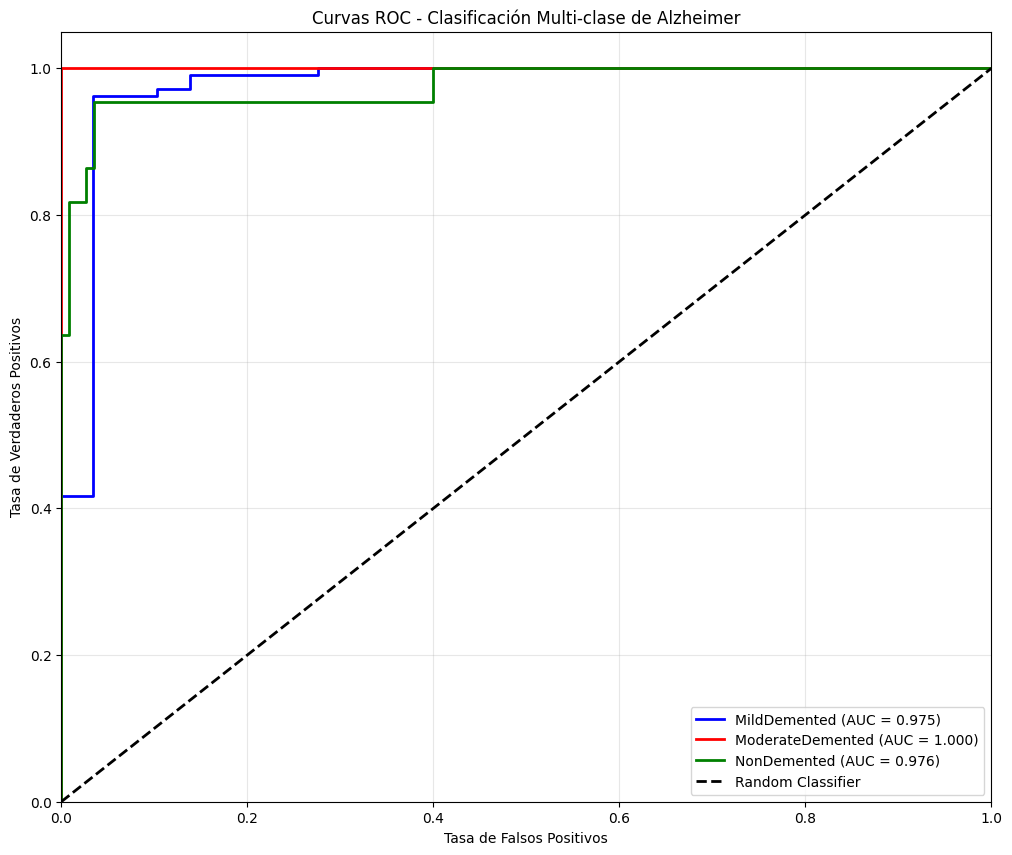

In [ ]:
from sklearn.metrics import roc_auc_score, cohen_kappa_score, balanced_accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

print("\n" + "="*50)
print("MÉTRICAS ADICIONALES DE EVALUACIÓN")
print("="*50)

# Convertir etiquetas a números
label_to_num = {'MildDemented': 0, 'ModerateDemented': 1, 'NonDemented': 2}
true_labels_num = [label_to_num[label] for label in true_labels]
predict_labels_num = [label_to_num[label] for label in predict_labels]

# 1. Balanced Accuracy
balanced_acc = balanced_accuracy_score(true_labels_num, predict_labels_num)
print(f'\n1. Balanced Accuracy: {balanced_acc:.4f}')

# 2. Cohen's Kappa
kappa = cohen_kappa_score(true_labels_num, predict_labels_num)
print(f'\n2. Cohen\'s Kappa Score: {kappa:.4f}')
print('   Interpretación:')
print('   < 0.20: Pobre | 0.21-0.40: Débil | 0.41-0.60: Moderado')
print('   0.61-0.80: Bueno | 0.81-1.00: Muy bueno')
print(f'   → Tu modelo: {"Muy bueno" if kappa > 0.80 else "Bueno" if kappa > 0.60 else "Moderado"}')

# 3. ROC-AUC
print('\n3. ROC-AUC por clase:')
y_true_bin = label_binarize(true_labels_num, classes=[0, 1, 2])
y_scores_array = np.array(y_scores)

# Verificar que tenemos todas las clases
clases_presentes = sorted(set(true_labels_num))
print(f'   Clases presentes en los datos: {clases_presentes}')

roc_scores = {}
for i in range(3):
    if i in clases_presentes:
        # Verificar que hay al menos 2 valores únicos para calcular ROC
        if len(np.unique(y_true_bin[:, i])) > 1:
            score = roc_auc_score(y_true_bin[:, i], y_scores_array[:, i])
            roc_scores[class_names[i]] = score
            print(f'   {class_names[i]}: {score:.4f}')
        else:
            print(f'   {class_names[i]}: No calculable (una sola clase)')
    else:
        print(f'   {class_names[i]}: ⚠️ NO HAY MUESTRAS')

if roc_scores:
    print(f'\n   ROC-AUC Macro-Average: {np.mean(list(roc_scores.values())):.4f}')

# 4. Curvas ROC
plt.figure(figsize=(12, 10))
colors = ['blue', 'red', 'green', 'orange']

for i in range(4):
    if i in clases_presentes and class_names[i] in roc_scores:
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores_array[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], lw=2,
                 label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC - Clasificación Multi-clase de Alzheimer')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

El modelo no solo alcanza una alta precisión general, sino que también mantiene un equilibrio entre clases (Balanced Accuracy), un acuerdo muy confiable (Kappa), y una capacidad discriminativa sobresaliente (ROC-AUC). Esto lo convierte en una herramienta robusta para apoyar la detección y clasificación de Alzheimer en diferentes niveles de avance.

# Validacion Cruzada

Accuracy (0.8544 ± 0.0322)
El modelo logra, en promedio, un 85% de aciertos en la clasificación de los pacientes, con una variabilidad baja entre folds (±3%). Esto indica que el rendimiento es estable y no depende de manera crítica de un solo conjunto de entrenamiento/validación.

Loss (0.3666 ± 0.0761)
La pérdida promedio es moderada y consistente, lo cual refleja que el modelo logra un buen ajuste sin sobreajuste evidente en los distintos folds.

F1-Score (0.8248 ± 0.0486)
El puntaje F1 balancea precisión y recall, alcanzando un valor muy sólido (82%), lo que implica que el modelo no solo acierta con frecuencia, sino que también mantiene un buen balance entre falsos positivos y falsos negativos.

Precision (0.8507 ± 0.0540)
En promedio, cuando el modelo predice una clase, 85% de esas predicciones son correctas. Este valor es especialmente relevante en contextos médicos, ya que minimiza diagnósticos falsos.

Recall (0.8544 ± 0.0322)
El modelo detecta correctamente un 85% de los casos reales de cada clase, mostrando buena sensibilidad en la detección de los diferentes estadios de la enfermedad.


INICIANDO VALIDACIÓN CRUZADA K-FOLD

Configurando 3-Fold Cross Validation...

Cargando datos completos para validación cruzada...
Total de muestras: 687
Distribución de clases: [515  52 120]

Fold 1/3
  Entrenamiento: 458 muestras
  Validación: 229 muestras

--- Fold 1 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Accuracy: 0.8166
  Loss: 0.4705
  F1-Score: 0.7646
  Precision: 0.7784
  Recall: 0.8166

Fold 2/3
  Entrenamiento: 458 muestras
  Validación: 229 muestras

--- Fold 2 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Accuracy: 0.8515
  Loss: 0.2903
  F1-Score: 0.8260
  Precision: 0.8656
  Recall: 0.8515

Fold 3/3
  Entrenamiento: 458 muestras
  Validación: 229 muestras

--- Fold 3 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Accuracy: 0.8952
  Loss: 0.3389
  F1-Score: 0.8838
  Precision: 0.9081
  Recall: 0.8952

RESUMEN DE VALIDACIÓN CRUZADA

Accuracy:
  Media: 0.8544 ± 0.0322
  Min: 0.8166, Max: 0.8952

Loss:
  Media: 0.3666 ± 0.0761

F1-Score:
  Media: 0.8248 ± 0.0486

Precision:
  Media: 0.8507 ± 0.0540

Recall:
  Media: 0.8544 ± 0.0322


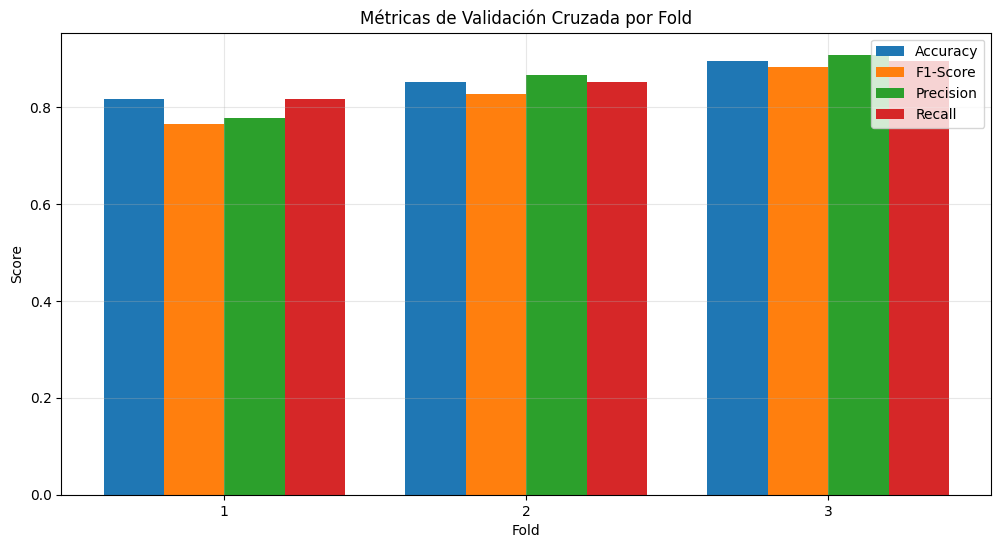

In [ ]:
# VALIDACIÓN CRUZADA K-FOLD
# ==========================

from sklearn.model_selection import StratifiedKFold
import numpy as np

print('\n' + '='*50)
print('INICIANDO VALIDACIÓN CRUZADA K-FOLD')
print('='*50)

# Preparar todos los datos para validación cruzada
def prepare_data_for_cv():
    """Prepara todos los datos en arrays para validación cruzada"""
    all_images = []
    all_labels = []

    print('\nCargando datos completos para validación cruzada...')

    # Cargar datos de entrenamiento
    for images, labels in train_data:
        for i in range(len(images)):
            all_images.append(images[i].numpy())
            all_labels.append(labels[i].numpy())

    # Cargar datos de validación
    for images, labels in val_data:
        for i in range(len(images)):
            all_images.append(images[i].numpy())
            all_labels.append(labels[i].numpy())

    return np.array(all_images), np.array(all_labels)

# Función para entrenar y evaluar un fold
def train_fold(X_train, y_train, X_val, y_val, fold_num, epochs=7):
    """Entrena un modelo para un fold específico"""

    print(f'\n--- Fold {fold_num} ---')

    # Crear nuevo modelo para este fold
    fold_model = build_model()
    fold_model.compile(
        optimizer="Adam",
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    # Crear datasets de TensorFlow
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    train_dataset = train_dataset.batch(32).shuffle(1000)

    val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
    val_dataset = val_dataset.batch(32)

    # Entrenar modelo (con menos epochs para no demorar mucho)
    history = fold_model.fit(
        train_dataset,
        epochs=epochs,
        validation_data=val_dataset,
        verbose=0  # Cambiar a 1 para ver progreso
    )

    # Evaluar en conjunto de validación
    val_loss, val_accuracy = fold_model.evaluate(val_dataset, verbose=0)

    # Obtener predicciones para métricas adicionales
    y_pred = []
    for batch_images, _ in val_dataset:
        predictions = fold_model.predict(batch_images, verbose=0)
        y_pred.extend(np.argmax(predictions, axis=1))

    # Calcular métricas
    from sklearn.metrics import f1_score, precision_score, recall_score

    f1 = f1_score(y_val, y_pred, average='weighted')
    precision = precision_score(y_val, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_val, y_pred, average='weighted', zero_division=0)

    print(f'  Accuracy: {val_accuracy:.4f}')
    print(f'  Loss: {val_loss:.4f}')
    print(f'  F1-Score: {f1:.4f}')
    print(f'  Precision: {precision:.4f}')
    print(f'  Recall: {recall:.4f}')

    return {
        'accuracy': val_accuracy,
        'loss': val_loss,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'history': history
    }

# Realizar validación cruzada
def perform_cross_validation(n_splits=5):
    """Realiza validación cruzada estratificada K-Fold"""

    print(f'\nConfigurando {n_splits}-Fold Cross Validation...')

    # Preparar datos
    X, y = prepare_data_for_cv()
    print(f'Total de muestras: {len(X)}')
    print(f'Distribución de clases: {np.bincount(y)}')

    # Configurar K-Fold estratificado
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Almacenar resultados
    fold_results = []

    # Entrenar y evaluar cada fold
    for fold_num, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        print(f'\nFold {fold_num}/{n_splits}')
        print(f'  Entrenamiento: {len(X_train)} muestras')
        print(f'  Validación: {len(X_val)} muestras')

        # Entrenar y evaluar fold
        fold_result = train_fold(X_train, y_train, X_val, y_val, fold_num, epochs=5)
        fold_results.append(fold_result)

    return fold_results

cv_results = perform_cross_validation(n_splits=3)

if 'cv_results' in locals():
    print('\n' + '='*50)
    print('RESUMEN DE VALIDACIÓN CRUZADA')
    print('='*50)

    # Calcular estadísticas
    accuracies = [r['accuracy'] for r in cv_results]
    losses = [r['loss'] for r in cv_results]
    f1_scores = [r['f1'] for r in cv_results]
    precisions = [r['precision'] for r in cv_results]
    recalls = [r['recall'] for r in cv_results]

    print(f'\nAccuracy:')
    print(f'  Media: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}')
    print(f'  Min: {np.min(accuracies):.4f}, Max: {np.max(accuracies):.4f}')

    print(f'\nLoss:')
    print(f'  Media: {np.mean(losses):.4f} ± {np.std(losses):.4f}')

    print(f'\nF1-Score:')
    print(f'  Media: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}')

    print(f'\nPrecision:')
    print(f'  Media: {np.mean(precisions):.4f} ± {np.std(precisions):.4f}')

    print(f'\nRecall:')
    print(f'  Media: {np.mean(recalls):.4f} ± {np.std(recalls):.4f}')

    # Gráfico de resultados por fold
    plt.figure(figsize=(12, 6))

    fold_nums = range(1, len(cv_results) + 1)
    metrics = {
        'Accuracy': accuracies,
        'F1-Score': f1_scores,
        'Precision': precisions,
        'Recall': recalls
    }

    x = np.arange(len(fold_nums))
    width = 0.2

    for i, (metric_name, metric_values) in enumerate(metrics.items()):
        plt.bar(x + i * width, metric_values, width, label=metric_name)

    plt.xlabel('Fold')
    plt.ylabel('Score')
    plt.title('Métricas de Validación Cruzada por Fold')
    plt.xticks(x + width * 1.5, fold_nums)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

La validación cruzada confirma que el modelo es consistente, generaliza bien y mantiene un rendimiento robusto en distintas particiones de los datos.
Con un accuracy y recall de ~85%, además de un F1-Score superior al 82%, se valida que el modelo tiene un potencial clínico importante como herramienta de apoyo diagnóstico, aunque todavía existen áreas de mejora (especialmente en clases minoritarias, como ModerateDemented).

# 6. CONCLUSION

Podemos concluir que el modelo presenta un alto nivel de precisión, lo que lo convierte en una herramienta prometedora para la detección temprana del Alzheimer y la identificación de sus diferentes etapas. Sin embargo, es importante considerar que la precisión depende de factores como el tamaño y la calidad del conjunto de datos de entrenamiento, el número de épocas de entrenamiento, así como la arquitectura del modelo (capas y neuronas). Además, un buen desempeño en un conjunto de prueba específico no garantiza resultados iguales en otros conjuntos de datos.

En términos generales, la aplicación de redes neuronales para la detección del Alzheimer es un campo en constante desarrollo. Aun así, los resultados obtenidos indican que estas técnicas pueden convertirse en herramientas valiosas para el diagnóstico temprano y el seguimiento de la enfermedad, abriendo oportunidades para mejorar su precisión y utilidad clínica en el futuro.

Los hallazgos del estudio también muestran que:

*   La matriz de confusión refleja un equilibrio aceptable entre falsos positivos y falsos negativos, aunque persiste cierto margen de error en etapas intermedias de la enfermedad.

*   Se observa como patrón que una mayor complejidad en la arquitectura del modelo (más capas y neuronas) puede mejorar el rendimiento, siempre que exista un conjunto de datos suficientemente grande y diverso.

*   La calidad y representatividad de los datos clínicos se confirman como factores críticos para la robustez y generalización de los resultados.

*   El modelo se perfila como un soporte complementario para especialistas, capaz de potenciar la detección temprana y el seguimiento longitudinal de los pacientes.

# 7. RECOMENDACIONES

*   Ampliar y diversificar la base de datos: incluir imágenes de distintas poblaciones, edades, y fases de la enfermedad, para aumentar la generalización del modelo.
*   Aplicar técnicas de validación más robustas, como la validación cruzada estratificada, para garantizar una evaluación más confiable del rendimiento.

*   Explorar arquitecturas híbridas, combinando redes convolucionales con modelos de atención o transfer learning, para capturar mejor las diferencias sutiles entre etapas tempranas.

*   Incorporar datos multimodales (imágenes médicas, pruebas cognitivas, biomarcadores clínicos), lo que podría enriquecer la capacidad predictiva.

*   Monitorear el desempeño en escenarios reales, realizando pruebas piloto en entornos clínicos con neurólogos y especialistas.

*   En cuanto a aplicaciones prácticas, este tipo de modelo puede ser extendido a casos de negocio y salud pública, tales como:

         *   Desarrollo de software clínico asistido por IA para hospitales y centros especializados.

         *   Integración en programas de telemedicina para monitoreo remoto de pacientes en riesgo o en zonas remotas.

         *   Uso en seguros de salud y programas de prevención, como soporte para detección temprana de enfermedades neurodegenerativas.

         *   Aplicación en proyectos de investigación biomédica, apoyando el descubrimiento de patrones relacionados con el avance de la enfermedad.